# Nghiên cứu nhận dạng ARX cho nhà kính mini

Mục tiêu:
- Đánh giá baseline ARX của nhà kính với cấu trúc và mức độ bằng chứng phù hợp cho một báo cáo kiểu nghiên cứu.
- Nhấn mạnh phạm vi dữ liệu 1 năm, khả năng thu hồi tham số, dự đoán dài hạn, chẩn đoán phần dư và trade-off giữa các cấu trúc mô hình.


## Câu hỏi nghiên cứu

- Baseline ARX(2,2,1) có thu hồi đúng hướng tác động vật lý thật của từng actuator và từng thành phần nhiễu hay không?
- Hiệu năng free-run giảm bao nhiêu so với dự đoán 1 bước, và khoảng cách đó có được giải thích bởi nhiễu quá trình hay không?
- Cần những biểu đồ chẩn đoán nào để có thể lập luận rằng mô hình đáng tin về mặt thống kê, chứ không chỉ đẹp về mặt thị giác?


## Quy trình

1. Cấu hình thí nghiệm và kiểu trình bày biểu đồ.
2. Chạy toàn bộ pipeline và tạo các bảng trung gian.
3. Mô tả bộ dữ liệu và chế độ vận hành.
4. Phân tích khả năng thu hồi tham số, chất lượng dự đoán, hành vi phần dư và việc lựa chọn mô hình.
5. Kết luận về điểm mạnh, giới hạn và những gì baseline có thể hoặc chưa thể hỗ trợ.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

from arx_pipeline import DataConfig, ModelConfig, SplitConfig, run_pipeline, save_artifact
from arx_reporting import (
    behavior_frame,
    combined_prediction_frame,
    contribution_frame,
    grouped_metrics,
    impulse_response_frame,
    model_comparison_frame,
    monthly_actuator_summary,
    monthly_setpoint_summary,
    monthly_signal_summary,
    parameter_frame,
    rolling_rmse,
    selection_metric_grid,
    standardized_parameter_frame,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

DATA_CONFIG = DataConfig(
    csv_path=Path('greenhouse_data.csv'),
    generator_script_path=Path('data_generator.py'),
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
    generated_days=365,
    generated_sampling_seconds=300,
    generated_seed=42,
    generated_start_date='2025-01-01',
)
SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)
MODEL_CONFIG = ModelConfig(na=2, nb=2, nk=1, include_intercept=False)

def plot_heatmap(ax, grid_df, title, cmap='viridis', fmt='{:.3f}'):
    if grid_df.empty:
        ax.set_visible(False)
        return
    data = grid_df.to_numpy(dtype=float)
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(grid_df.columns)))
    ax.set_xticklabels(grid_df.columns.tolist())
    ax.set_yticks(range(len(grid_df.index)))
    ax.set_yticklabels(grid_df.index.tolist())
    ax.set_xlabel('nb')
    ax.set_ylabel('na')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt.format(data[i, j]), ha='center', va='center', color='white', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def display_research_note(title, lines):
    payload = [f'### {title}', ''] + [f'- {line}' for line in lines]
    display(Markdown('\n'.join(payload)))


In [2]:
results = run_pipeline(DATA_CONFIG, SPLIT_CONFIG, MODEL_CONFIG)
save_artifact(results)

df_full = results['df_full']
df_train = results['df_train']
df_val = results['df_val']
df_test = results['df_test']

behavior_df = behavior_frame(results)
params_df = parameter_frame(results)
std_param_df = standardized_parameter_frame(results, split_key='train')
contrib_df = contribution_frame(results, split_key='train')
impulse_df = impulse_response_frame(results, split_key='train', horizon=48, pulse_mode='std')
prediction_df = combined_prediction_frame(results)
monthly_signal_df = monthly_signal_summary(df_full)
monthly_actuator_df = monthly_actuator_summary(df_full)
monthly_setpoint_df = monthly_setpoint_summary(df_full)
monthly_metrics_df = grouped_metrics(prediction_df[prediction_df['split'].isin(['Validation', 'Test'])], ['split', 'Month'])
model_cmp_df = model_comparison_frame(results)
selection_df = results['model_selection'].copy()
selection_grid_nk1 = selection_metric_grid(selection_df, 'RMSE_sim', nk=1)
selection_grid_nk2 = selection_metric_grid(selection_df, 'RMSE_sim', nk=2)

overview = results['dataset_overview']
summary_series = pd.Series({
    'data_source': results['data_source'],
    'rows': overview['rows'],
    'timestamp_start': overview['timestamp_start'],
    'timestamp_end': overview['timestamp_end'],
    'months_present': overview['months_present'],
    'seasons_present': overview['seasons_present'],
    'rank_x_train': overview['rank_x_train'],
    'n_params': overview['n_params'],
    'condition_number_xtx': round(overview['condition_number_xtx'], 2),
    'sign_ok_count': int(params_df['sign_ok'].sum()),
    'sign_total_count': int(len(params_df)),
    'val_fit_1step': round(results['val']['metrics_1step']['FIT'], 3),
    'val_fit_12step': round(results['val']['metrics_n_step']['FIT'], 3),
    'val_fit_sim': round(results['val']['metrics_sim']['FIT'], 3),
    'test_fit_sim': round(results['test']['metrics_sim']['FIT'], 3),
    'val_theoretical_fit_sim': round(results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 3),
    'test_theoretical_fit_sim': round(results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 3),
})


## Đánh giá tổng quan

Notebook không nên dừng lại ở một điểm số 1 bước đẹp. Một kết quả nhận dạng đáng tin cần kết hợp:
- dữ liệu có phạm vi đại diện,
- dấu tham số phù hợp với vật lý sinh dữ liệu,
- phần dư có hành vi giống nhiễu chưa giải thích,
- và hiệu năng dài hạn được diễn giải tương quan với giới hạn xác định.


In [3]:
key_findings = pd.DataFrame(
    [
        {'Phát hiện': 'Full-year coverage', 'Bằng chứng': f"{summary_series['months_present']}"},
        {'Phát hiện': 'Thu hồi dấu tham số', 'Bằng chứng': f"{summary_series['sign_ok_count']} / {summary_series['sign_total_count']} correct"},
        {'Phát hiện': 'Validation FIT 1 bước', 'Bằng chứng': f"{summary_series['val_fit_1step']:.3f}%"},
        {'Phát hiện': 'Validation FIT free-run', 'Bằng chứng': f"{summary_series['val_fit_sim']:.3f}%"},
        {'Phát hiện': 'Validation trần xác định', 'Bằng chứng': f"{summary_series['val_theoretical_fit_sim']:.3f}%"},
        {'Phát hiện': 'Residual whiteness trên validation', 'Bằng chứng': str(results['val']['residual_diagnostics']['ljung_box']['passes_all_lags'])},
    ]
)
summary_series, key_findings


(data_source                                 CSV:greenhouse_data.csv
 rows                                                         105120
 timestamp_start                                 2025-01-01 00:00:00
 timestamp_end                                   2025-12-31 23:55:00
 months_present              [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
 seasons_present                    [autumn, spring, summer, winter]
 rank_x_train                                                     14
 n_params                                                         14
 condition_number_xtx                                    56303331.05
 sign_ok_count                                                    14
 sign_total_count                                                 14
 val_fit_1step                                                91.641
 val_fit_12step                                               73.109
 val_fit_sim                                                  42.959
 test_fit_sim                     

## Thiết lập thí nghiệm

Phần này ghi lại cấu hình baseline và thống kê vận hành của từng split. Trong một bài báo, đây là mức tối thiểu cần có để diễn giải các metric ở phần sau.


In [4]:
config_df = pd.DataFrame(
    [
        {'Khối': 'Data', 'Cấu hình': 'Nguồn', 'Giá trị': results['data_source']},
        {'Khối': 'Data', 'Cấu hình': 'Số ngày', 'Giá trị': DATA_CONFIG.generated_days},
        {'Khối': 'Data', 'Cấu hình': 'Số giây lấy mẫu', 'Giá trị': DATA_CONFIG.generated_sampling_seconds},
        {'Khối': 'Split', 'Cấu hình': 'Tỉ lệ train', 'Giá trị': SPLIT_CONFIG.train_ratio},
        {'Khối': 'Split', 'Cấu hình': 'Tỉ lệ validation', 'Giá trị': SPLIT_CONFIG.val_ratio},
        {'Khối': 'Split', 'Cấu hình': 'Tỉ lệ test', 'Giá trị': SPLIT_CONFIG.test_ratio},
        {'Khối': 'Model', 'Cấu hình': 'na', 'Giá trị': MODEL_CONFIG.na},
        {'Khối': 'Model', 'Cấu hình': 'nb', 'Giá trị': MODEL_CONFIG.nb},
        {'Khối': 'Model', 'Cấu hình': 'nk', 'Giá trị': MODEL_CONFIG.nk},
        {'Khối': 'Model', 'Cấu hình': 'include_intercept', 'Giá trị': MODEL_CONFIG.include_intercept},
    ]
)
config_df, behavior_df.round(3)


(    Khối           Cấu hình                  Giá trị
 0   Data              Nguồn  CSV:greenhouse_data.csv
 1   Data            Số ngày                      365
 2   Data    Số giây lấy mẫu                      300
 3  Split        Tỉ lệ train                      0.6
 4  Split   Tỉ lệ validation                      0.2
 5  Split         Tỉ lệ test                      0.2
 6  Model                 na                        2
 7  Model                 nb                        2
 8  Model                 nk                        1
 9  Model  include_intercept                    False,
         label   rows      timestamp_start        timestamp_end  \
 0       Train  63072  2025-01-01 00:00:00  2025-08-07 23:55:00   
 1  Validation  21024  2025-08-08 00:00:00  2025-10-19 23:55:00   
 2        Test  21024  2025-10-20 00:00:00  2025-12-31 23:55:00   
 
              months_present           seasons_present  drip_on_pct  \
 0  [1, 2, 3, 4, 5, 6, 7, 8]  [spring, summer, winter]        22

## Đặc trưng bộ dữ liệu

Notebook ban đầu còn thiếu một số hình mang tính báo cáo nghiên cứu: tổng quan vận hành cả năm, phân bố theo tháng, sự thay đổi duty cycle của actuator và tỷ lệ bám setpoint. Các nội dung đó được bổ sung bên dưới.


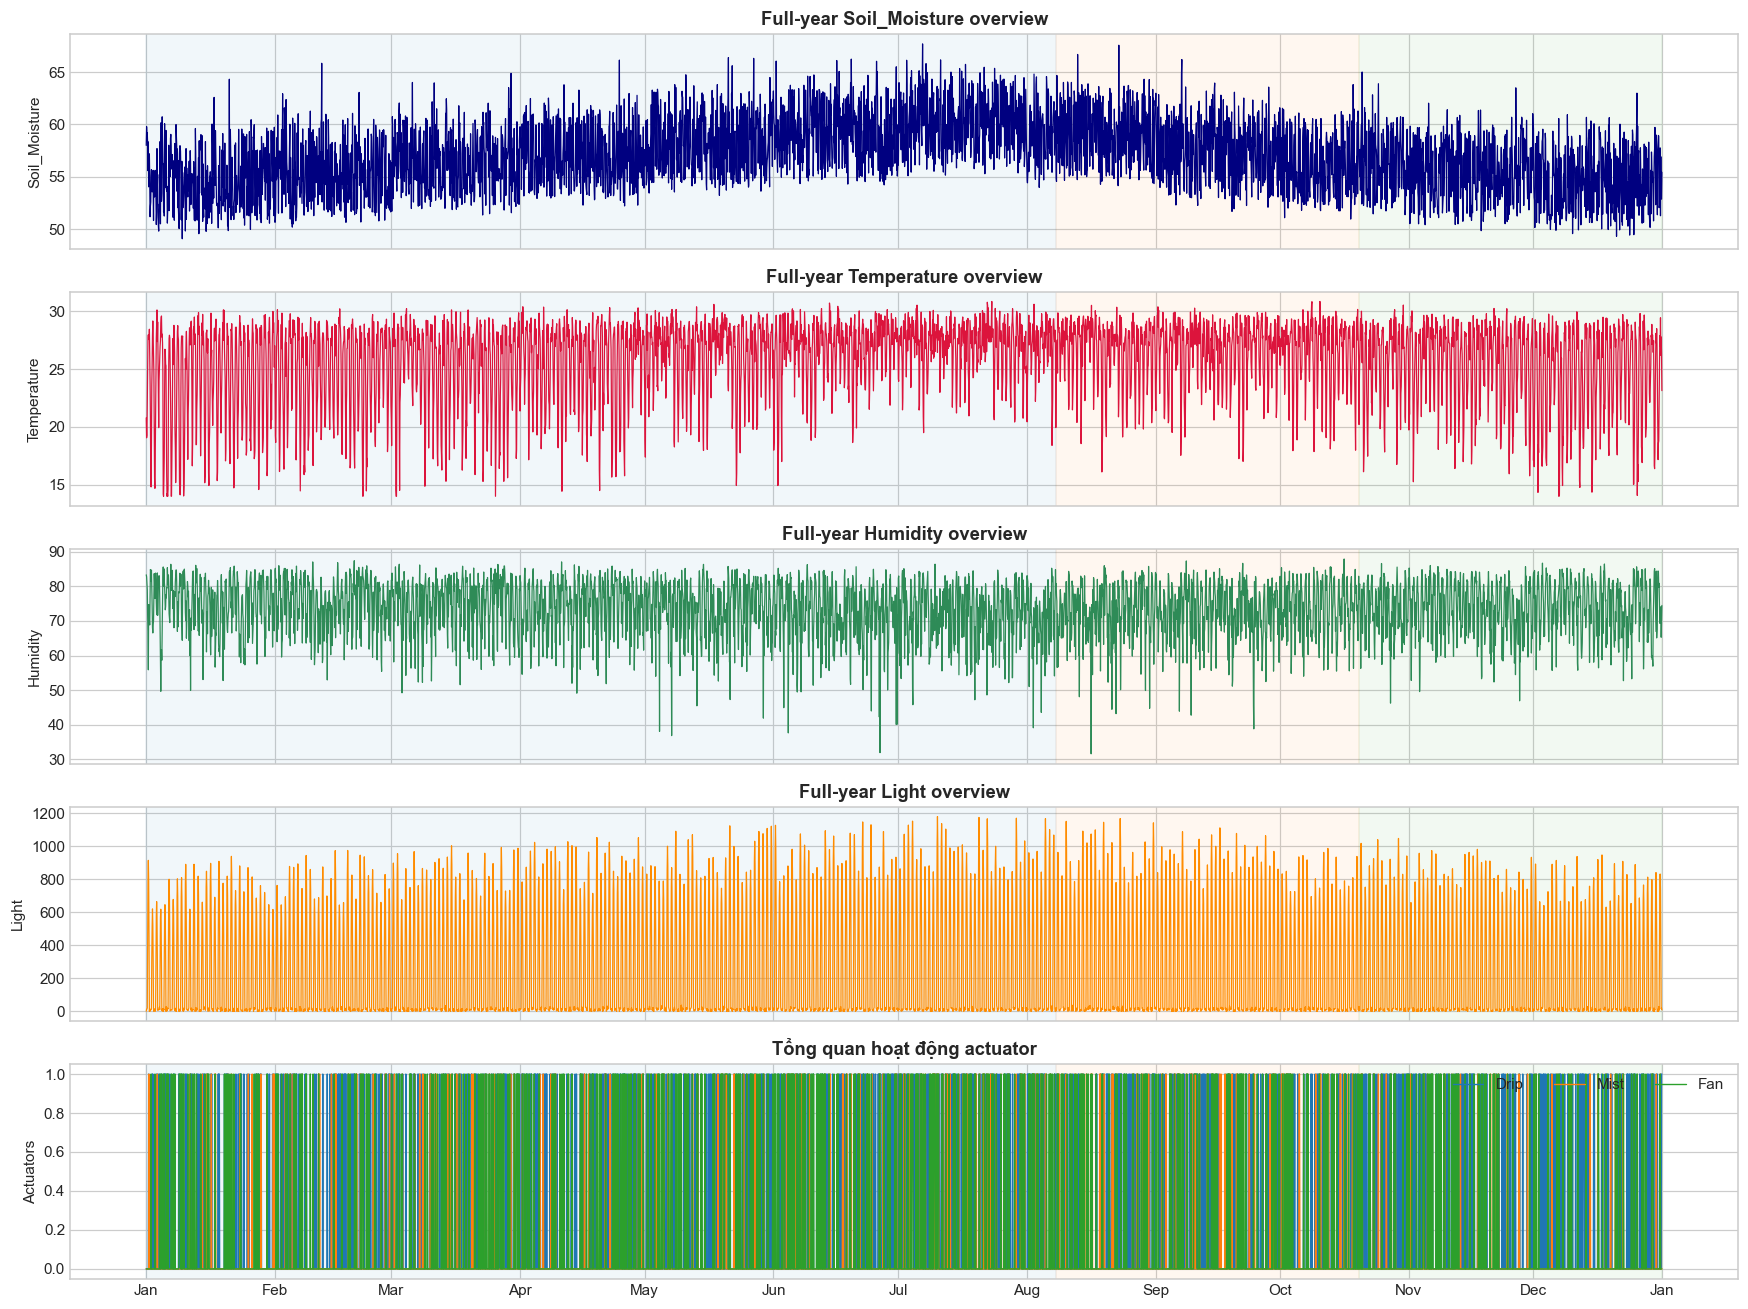

### Diễn giải bộ dữ liệu

- Bộ dữ liệu trải dài [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] qua ['autumn', 'spring', 'summer', 'winter'], nên phần đánh giá không còn bị bó hẹp trong một chế độ vận hành của riêng một tháng.
- Chronological splitting preserves temporal causality with 63072 training samples, 21024 validation samples, and 21024 test samples.
- Condition number của hồi quy trên tập train là 56303331.05; giá trị này đủ cao để biện minh cho các biểu đồ tầm quan trọng có xét thang đo, nhưng chưa cao đến mức khiến việc ước lượng trở nên vô nghĩa về mặt số học.

In [5]:
plot_df = df_full.iloc[::24].copy()
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
signal_cols = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light']
signal_colors = ['navy', 'crimson', 'seagreen', 'darkorange']
for ax, col, color in zip(axes[:4], signal_cols, signal_colors):
    ax.plot(plot_df['Timestamp'], plot_df[col], color=color, linewidth=0.8)
    ax.set_ylabel(col)
    ax.set_title(f'Full-year {col} overview')

axes[4].plot(plot_df['Timestamp'], plot_df['Drip'], label='Drip', linewidth=0.9)
axes[4].plot(plot_df['Timestamp'], plot_df['Mist'], label='Mist', linewidth=0.9)
axes[4].plot(plot_df['Timestamp'], plot_df['Fan'], label='Fan', linewidth=0.9)
axes[4].set_ylabel('Actuators')
axes[4].legend(ncol=3, loc='upper right')
axes[4].set_title('Tổng quan hoạt động actuator')

for ax in axes:
    ax.axvspan(df_train['Timestamp'].iloc[0], df_train['Timestamp'].iloc[-1], color='tab:blue', alpha=0.06)
    ax.axvspan(df_val['Timestamp'].iloc[0], df_val['Timestamp'].iloc[-1], color='tab:orange', alpha=0.06)
    ax.axvspan(df_test['Timestamp'].iloc[0], df_test['Timestamp'].iloc[-1], color='tab:green', alpha=0.06)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()
display_research_note(
    'Diễn giải bộ dữ liệu',
    [
        f"Bộ dữ liệu trải dài {summary_series['months_present']} qua {summary_series['seasons_present']}, nên phần đánh giá không còn bị bó hẹp trong một chế độ vận hành của riêng một tháng.",
        f"Chronological splitting preserves temporal causality with {len(df_train)} training samples, {len(df_val)} validation samples, and {len(df_test)} test samples.",
        f"Condition number của hồi quy trên tập train là {summary_series['condition_number_xtx']:.2f}; giá trị này đủ cao để biện minh cho các biểu đồ tầm quan trọng có xét thang đo, nhưng chưa cao đến mức khiến việc ước lượng trở nên vô nghĩa về mặt số học.",
    ],
)


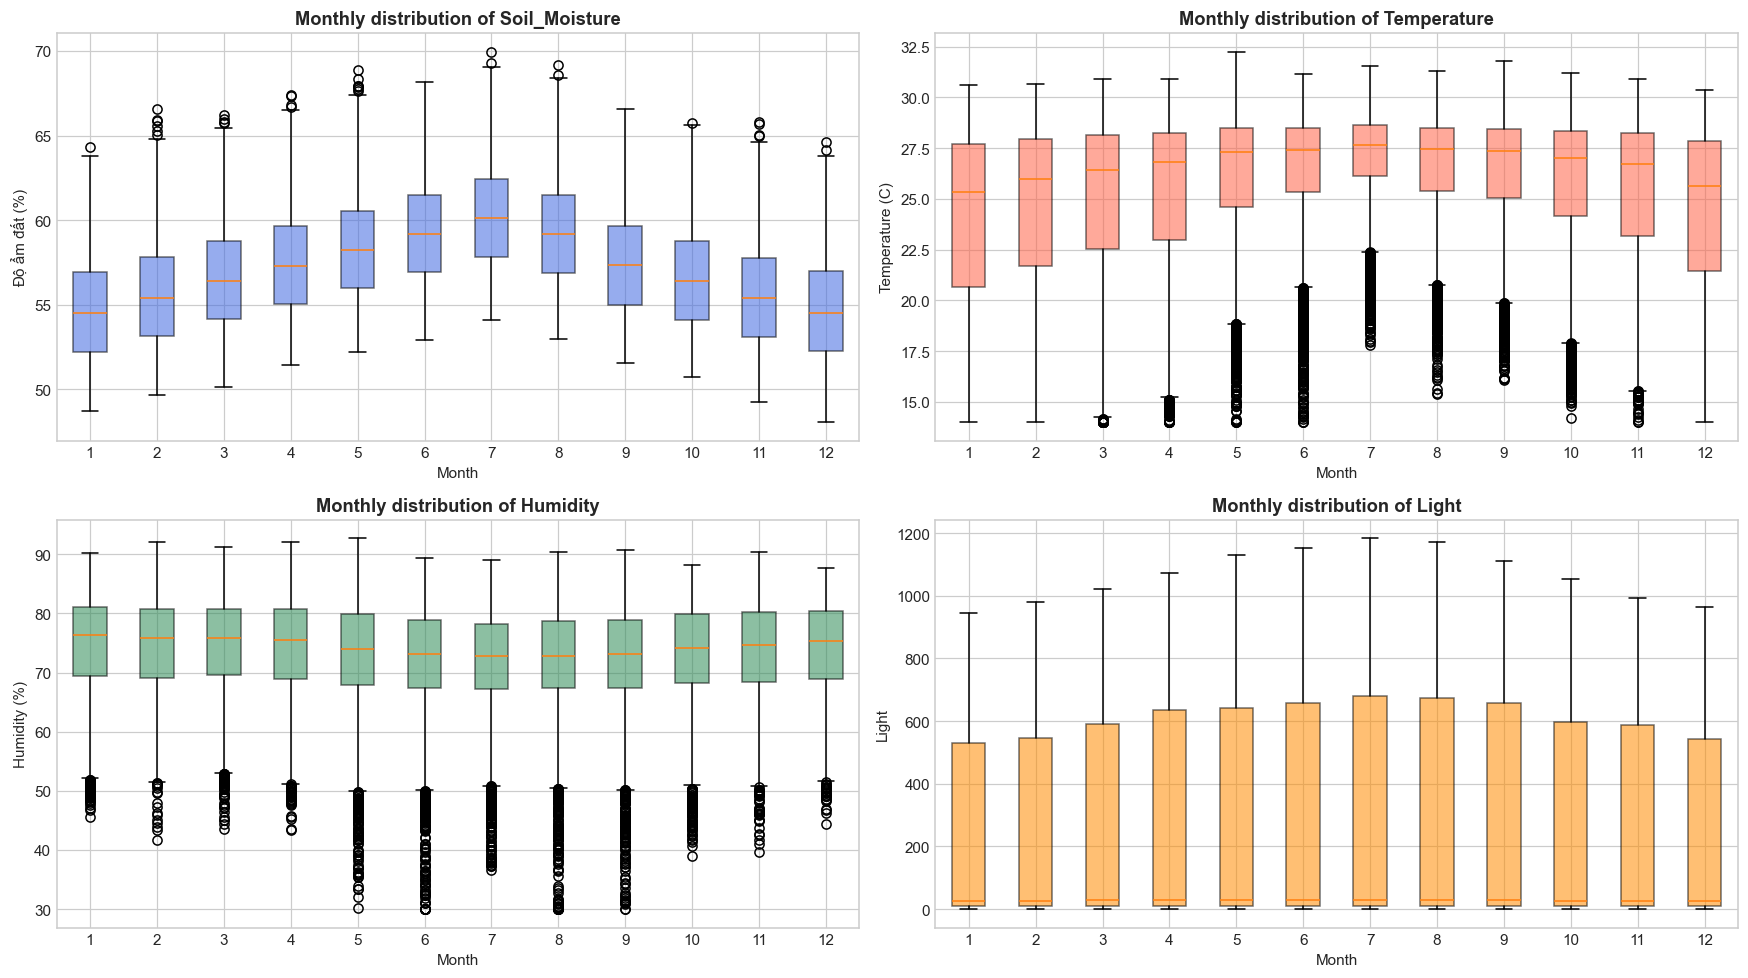

,Month,soil_mean,soil_std,temp_mean,humi_mean,light_mean
0,1,54.630,2.846,23.989,74.794,249.935
1,2,55.535,2.835,24.680,74.459,258.135
2,3,56.482,2.810,25.094,74.498,278.222
3,4,57.400,2.804,25.450,74.208,296.648
4,5,58.309,2.795,26.285,72.969,301.075
5,6,59.247,2.754,26.651,72.155,307.663
6,7,60.162,2.762,27.097,71.973,319.766
7,8,59.226,2.780,26.664,72.197,315.924
8,9,57.355,2.786,26.539,72.274,307.257
9,10,56.462,2.802,25.962,73.345,280.110


### Diễn giải tính mùa vụ

- Monthly mean soil moisture varies by 5.53 percentage points, which confirms that the process visits meaningfully different operating regimes over the year.
- Temperature mean shifts by 3.11 C and humidity mean shifts by 2.82%, so the exogenous environment is genuinely seasonal rather than nearly constant.
- These distribution shifts explain why month-wise diagnostics are necessary instead of a single pooled performance number.

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
box_specs = [
    ('Soil_Moisture', 'Độ ẩm đất (%)', 'royalblue'),
    ('Temperature', 'Temperature (C)', 'tomato'),
    ('Humidity', 'Humidity (%)', 'seagreen'),
    ('Light', 'Light', 'darkorange'),
]
for ax, (col, ylabel, color) in zip(axes.flat, box_specs):
    data = [df_full.loc[df_full['Month'] == month, col].to_numpy() for month in sorted(df_full['Month'].unique())]
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor=color, alpha=0.55))
    ax.set_title(f'Monthly distribution of {col}')
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

display(monthly_signal_df.round(3))
display_research_note(
    'Diễn giải tính mùa vụ',
    [
        f"Monthly mean soil moisture varies by {monthly_signal_df['soil_mean'].max() - monthly_signal_df['soil_mean'].min():.2f} percentage points, which confirms that the process visits meaningfully different operating regimes over the year.",
        f"Temperature mean shifts by {monthly_signal_df['temp_mean'].max() - monthly_signal_df['temp_mean'].min():.2f} C and humidity mean shifts by {monthly_signal_df['humi_mean'].max() - monthly_signal_df['humi_mean'].min():.2f}%, so the exogenous environment is genuinely seasonal rather than nearly constant.",
        'These distribution shifts explain why month-wise diagnostics are necessary instead of a single pooled performance number.',
    ],
)


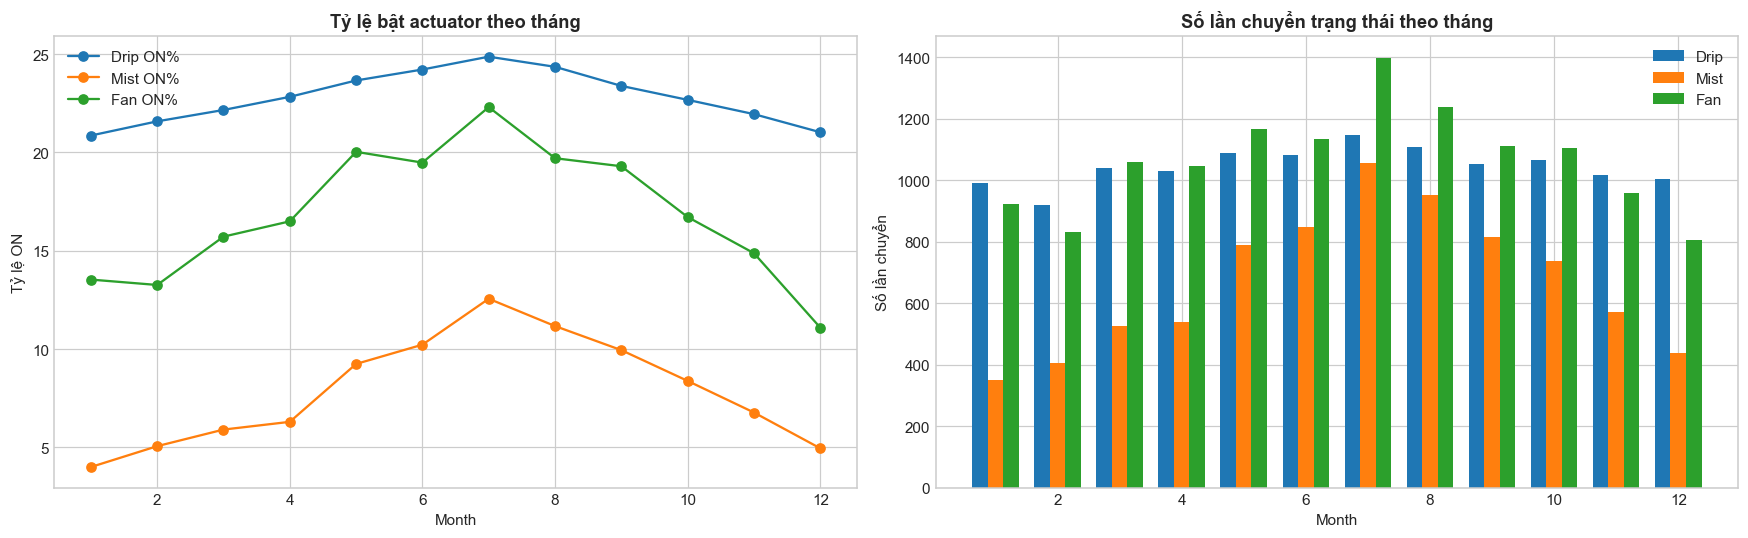

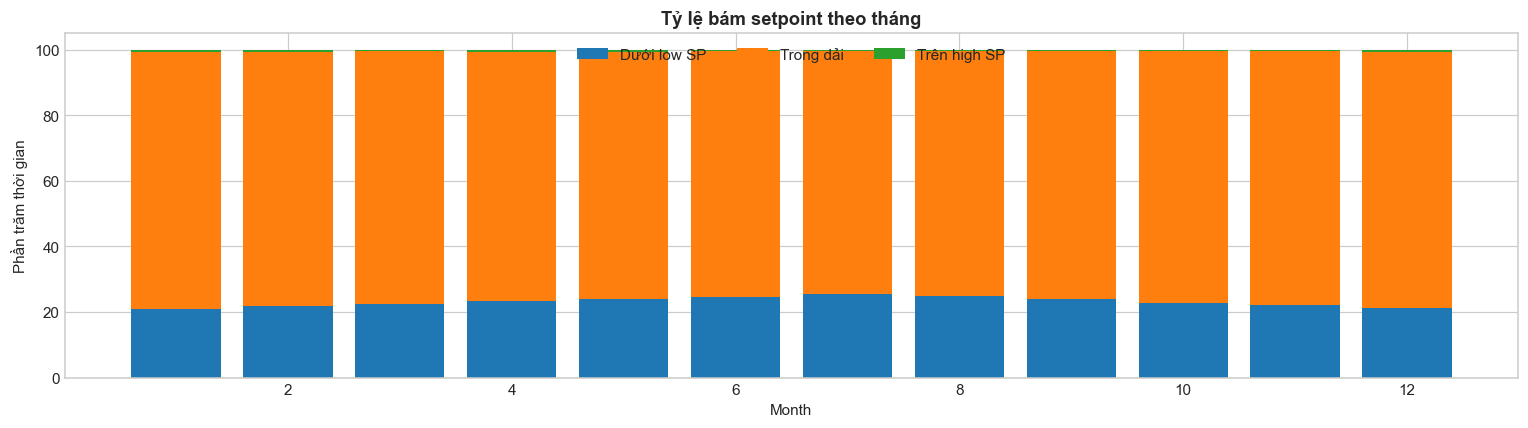

### Diễn giải actuator và setpoint

- Drip duty cycle peaks in month 7, Mist peaks in month 7, and Fan peaks in month 7; the controller is therefore exciting different actuators under different seasonal loads.
- Nhà kính duy trì bên trong dải setpoint độ ẩm đất trong khoảng 76.36% thời gian của cả năm tính theo trung bình, với các thời đoạn nằm dưới dải chiếm trung bình 23.08% thời gian.
- These occupancy ratios matter because identification quality is harder to trust if the process never visits the control boundaries that define the actual task.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
months = monthly_actuator_df['Month']

axes[0].plot(months, monthly_actuator_df['drip_on_pct'], marker='o', label='Drip ON%')
axes[0].plot(months, monthly_actuator_df['mist_on_pct'], marker='o', label='Mist ON%')
axes[0].plot(months, monthly_actuator_df['fan_on_pct'], marker='o', label='Fan ON%')
axes[0].set_title('Tỷ lệ bật actuator theo tháng')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Tỷ lệ ON')
axes[0].legend()

width = 0.25
axes[1].bar(months - width, monthly_actuator_df['drip_switches'], width=width, label='Drip')
axes[1].bar(months, monthly_actuator_df['mist_switches'], width=width, label='Mist')
axes[1].bar(months + width, monthly_actuator_df['fan_switches'], width=width, label='Fan')
axes[1].set_title('Số lần chuyển trạng thái theo tháng')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Số lần chuyển')
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_setpoint_df['Month'], monthly_setpoint_df['below_sp_pct'], label='Dưới low SP')
ax.bar(monthly_setpoint_df['Month'], monthly_setpoint_df['inside_sp_pct'], bottom=monthly_setpoint_df['below_sp_pct'], label='Trong dải')
ax.bar(
    monthly_setpoint_df['Month'],
    monthly_setpoint_df['above_sp_pct'],
    bottom=monthly_setpoint_df['below_sp_pct'] + monthly_setpoint_df['inside_sp_pct'],
    label='Trên high SP',
)
ax.set_title('Tỷ lệ bám setpoint theo tháng')
ax.set_xlabel('Month')
ax.set_ylabel('Phần trăm thời gian')
ax.legend(ncol=3, loc='upper center')
plt.tight_layout()
plt.show()
peak_drip_month = int(monthly_actuator_df.loc[monthly_actuator_df['drip_on_pct'].idxmax(), 'Month'])
peak_mist_month = int(monthly_actuator_df.loc[monthly_actuator_df['mist_on_pct'].idxmax(), 'Month'])
peak_fan_month = int(monthly_actuator_df.loc[monthly_actuator_df['fan_on_pct'].idxmax(), 'Month'])
display_research_note(
    'Diễn giải actuator và setpoint',
    [
        f"Drip duty cycle peaks in month {peak_drip_month}, Mist peaks in month {peak_mist_month}, and Fan peaks in month {peak_fan_month}; the controller is therefore exciting different actuators under different seasonal loads.",
        f"Nhà kính duy trì bên trong dải setpoint độ ẩm đất trong khoảng {monthly_setpoint_df['inside_sp_pct'].mean():.2f}% thời gian của cả năm tính theo trung bình, với các thời đoạn nằm dưới dải chiếm trung bình {monthly_setpoint_df['below_sp_pct'].mean():.2f}% thời gian.",
        'These occupancy ratios matter because identification quality is harder to trust if the process never visits the control boundaries that define the actual task.',
    ],
)


## Nhận dạng tham số

Một phần nhận dạng theo phong cách nghiên cứu không chỉ dừng ở bảng hệ số. Nó cần cho thấy so sánh estimate-vs-true, khoảng tin cậy và độ ổn định của phần tự hồi quy.


In [8]:
params_display = params_df[[
    'name',
    'estimate',
    'true_value',
    'delta_vs_true',
    'sign_ok',
    'ci95_low',
    'ci95_high',
]].copy()
display(params_display.round(6))
display(pd.DataFrame(results['ar_roots']).round(6))


,name,estimate,true_value,delta_vs_true,sign_ok,ci95_low,ci95_high
0,a1,0.963098,0.96500,-0.001902,True,0.959824,0.966371
1,a2,0.026738,0.02500,0.001738,True,0.023358,0.030118
2,b_Temperature_1,-0.007410,-0.00800,0.000590,True,-0.012403,-0.002416
3,b_Temperature_2,-0.003922,-0.00400,0.000078,True,-0.008808,0.000964
4,b_Humidity_1,0.002567,0.00250,0.000067,True,0.000929,0.004206
5,b_Humidity_2,0.001029,0.00120,-0.000171,True,-0.000588,0.002646
6,b_Light_1,-0.000132,-0.00022,0.000088,True,-0.000270,0.000005
7,b_Light_2,-0.000194,-0.00010,-0.000094,True,-0.000334,-0.000055
8,b_Drip_1,1.251167,1.25000,0.001167,True,1.244526,1.257809
9,b_Drip_2,1.851585,1.85000,0.001585,True,1.840899,1.862271


,root_index,real,imag,magnitude
0,1,0.990103,0.0,0.990103
1,2,-0.027005,0.0,0.027005


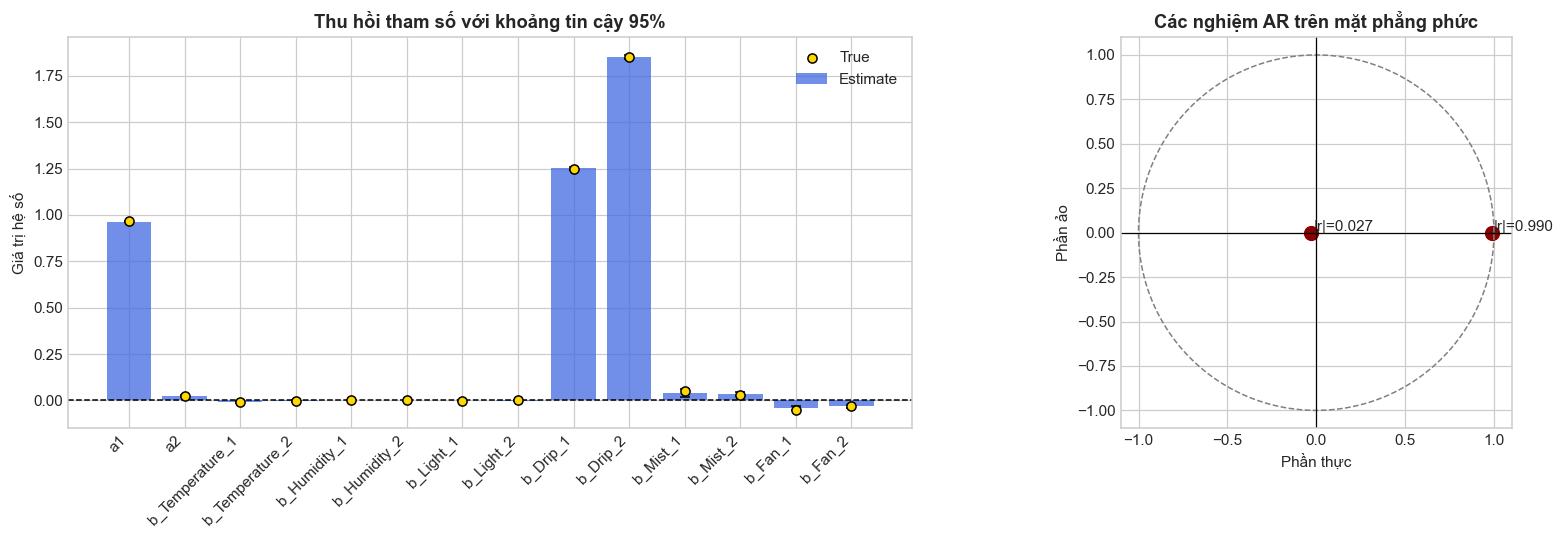

### Diễn giải tham số

- Mô hình thu hồi 14 trên 14 dấu hệ số đúng, đây là điều kiện đầu tiên để một baseline ARX có thể giải thích được về mặt vật lý.
- Các khoảng 95% bao phủ true value cho 14 tham số, và độ lớn nghiệm tự hồi quy lớn nhất là 0.990, vì vậy động học đã fit vẫn ổn định.
- Các term chi phối vẫn là a1=0.963, b_Drip_1=1.251, and b_Drip_2=1.852, khớp với logic vật lý đã chủ ý thiết kế trong generator theo hướng quán tính cộng với tưới.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(params_df))
axes[0].bar(x, params_df['estimate'], color=['royalblue' if ok else 'tomato' for ok in params_df['sign_ok']], alpha=0.75, label='Estimate')
axes[0].errorbar(x, params_df['estimate'], yerr=1.96 * params_df['std'], fmt='none', color='black', capsize=3, linewidth=1.1)
axes[0].scatter(x, params_df['true_value'], color='gold', edgecolor='black', zorder=3, label='True')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(params_df['name'], rotation=45, ha='right')
axes[0].set_title('Thu hồi tham số với khoảng tin cậy 95%')
axes[0].set_ylabel('Giá trị hệ số')
axes[0].legend()

roots_df = pd.DataFrame(results['ar_roots'])
theta_circle = np.linspace(0, 2 * np.pi, 400)
axes[1].plot(np.cos(theta_circle), np.sin(theta_circle), color='gray', linestyle='--', linewidth=1.0)
axes[1].scatter(roots_df['real'], roots_df['imag'], color='darkred', s=80)
for _, row in roots_df.iterrows():
    axes[1].text(row['real'] + 0.01, row['imag'] + 0.01, f"|r|={row['magnitude']:.3f}")
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].axvline(0.0, color='black', linewidth=0.8)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('Các nghiệm AR trên mặt phẳng phức')
axes[1].set_xlabel('Phần thực')
axes[1].set_ylabel('Phần ảo')
plt.tight_layout()
plt.show()
ci_cover = int(((params_df['true_value'] >= params_df['ci95_low']) & (params_df['true_value'] <= params_df['ci95_high'])).sum())
display_research_note(
    'Diễn giải tham số',
    [
        f"Mô hình thu hồi {int(params_df['sign_ok'].sum())} trên {len(params_df)} dấu hệ số đúng, đây là điều kiện đầu tiên để một baseline ARX có thể giải thích được về mặt vật lý.",
        f"Các khoảng 95% bao phủ true value cho {ci_cover} tham số, và độ lớn nghiệm tự hồi quy lớn nhất là {roots_df['magnitude'].max():.3f}, vì vậy động học đã fit vẫn ổn định.",
        f"Các term chi phối vẫn là a1={float(params_df.loc[params_df['name'] == 'a1', 'estimate'].iloc[0]):.3f}, b_Drip_1={float(params_df.loc[params_df['name'] == 'b_Drip_1', 'estimate'].iloc[0]):.3f}, and b_Drip_2={float(params_df.loc[params_df['name'] == 'b_Drip_2', 'estimate'].iloc[0]):.3f}, khớp với logic vật lý đã chủ ý thiết kế trong generator theo hướng quán tính cộng với tưới.",
    ],
)


## Mức độ quan trọng tham số có xét thang đo

Các hệ số ARX gốc được báo cáo theo đơn vị kỹ thuật ban đầu, nên độ lớn của chúng không thể so sánh trực tiếp giữa các regressor.
Ba hình tiếp theo trả lời một câu hỏi công bằng hơn: term nào quan trọng nhất sau khi đã tính đến thang đo biến, phân bố vận hành và tác động động học có độ trễ.


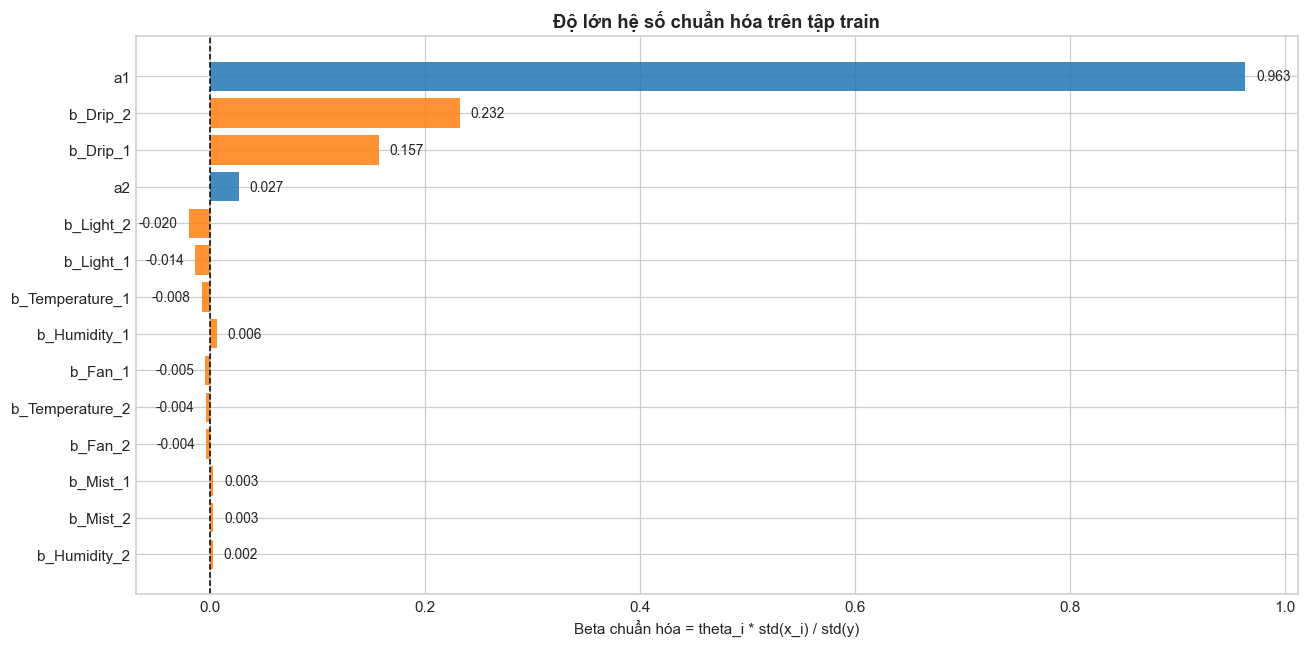

### Diễn giải hệ số chuẩn hóa

- This plot removes the misleading effect of mixed engineering units, so coefficient sizes can be compared on a common scale.
- Ba hiệu ứng chuẩn hóa lớn nhất là a1 (0.96), b_Drip_2 (0.23), b_Drip_1 (0.16), điều này xác nhận rằng quán tính và tưới vẫn là hai yếu tố chi phối ngay cả sau khi hiệu chỉnh thang đo.
- Small raw coefficients on Light or Humidity are not automatically unimportant; the fair comparison is their standardized impact after rescaling.

In [10]:
std_plot_df = std_param_df.sort_values('abs_standardized_beta', ascending=True).copy()
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#1f77b4' if name.startswith('a') else '#ff7f0e' for name in std_plot_df['name']]
bars = ax.barh(std_plot_df['name'], std_plot_df['standardized_beta'], color=bar_colors, alpha=0.85)
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Độ lớn hệ số chuẩn hóa trên tập train')
ax.set_xlabel('Beta chuẩn hóa = theta_i * std(x_i) / std(y)')
for bar, beta in zip(bars, std_plot_df['standardized_beta']):
    x_text = bar.get_width() + (0.01 if beta >= 0 else -0.01)
    ha = 'left' if beta >= 0 else 'right'
    ax.text(x_text, bar.get_y() + bar.get_height() / 2, f'{beta:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.show()
top_std = std_plot_df.sort_values('abs_standardized_beta', ascending=False).head(3)
top_std_text = ', '.join([f"{row['name']} ({row['standardized_beta']:.2f})" for _, row in top_std.iterrows()])
display_research_note(
    'Diễn giải hệ số chuẩn hóa',
    [
        'This plot removes the misleading effect of mixed engineering units, so coefficient sizes can be compared on a common scale.',
        f"Ba hiệu ứng chuẩn hóa lớn nhất là {top_std_text}, điều này xác nhận rằng quán tính và tưới vẫn là hai yếu tố chi phối ngay cả sau khi hiệu chỉnh thang đo.",
        'Small raw coefficients on Light or Humidity are not automatically unimportant; the fair comparison is their standardized impact after rescaling.',
    ],
)


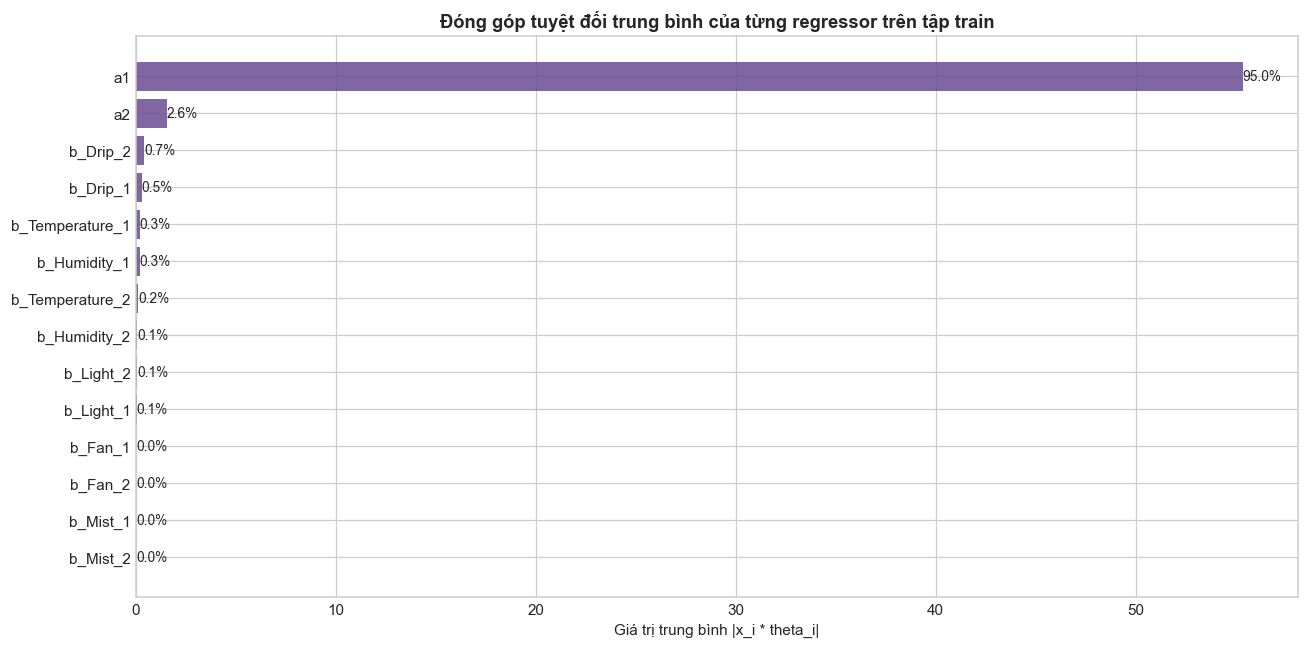

### Diễn giải mức đóng góp

- Average absolute contribution measures how much each regressor actually moves the fitted output over the observed operating distribution, not just how large its coefficient looks in isolation.
- Các thành phần đóng góp chi phối là a1 (95.0%), a2 (2.6%), b_Drip_2 (0.7%), điều này giải thích vì sao biểu đồ hệ số gốc tập trung chủ yếu quanh a1 và các term của drip.
- A regressor can have a visible coefficient yet still contribute little if its observed variation is small or if the controller rarely excites it.

In [11]:
contrib_plot_df = contrib_df.sort_values('mean_abs_contribution', ascending=True).copy()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(contrib_plot_df['name'], contrib_plot_df['mean_abs_contribution'], color='#6a4c93', alpha=0.85)
ax.set_title('Đóng góp tuyệt đối trung bình của từng regressor trên tập train')
ax.set_xlabel('Giá trị trung bình |x_i * theta_i|')
for bar, share in zip(bars, contrib_plot_df['contribution_share']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'{share * 100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
top_contrib = contrib_plot_df.sort_values('mean_abs_contribution', ascending=False).head(3)
top_contrib_text = ', '.join([f"{row['name']} ({row['contribution_share'] * 100:.1f}%)" for _, row in top_contrib.iterrows()])
display_research_note(
    'Diễn giải mức đóng góp',
    [
        'Average absolute contribution measures how much each regressor actually moves the fitted output over the observed operating distribution, not just how large its coefficient looks in isolation.',
        f"Các thành phần đóng góp chi phối là {top_contrib_text}, điều này giải thích vì sao biểu đồ hệ số gốc tập trung chủ yếu quanh a1 và các term của drip.",
        'A regressor can have a visible coefficient yet still contribute little if its observed variation is small or if the controller rarely excites it.',
    ],
)


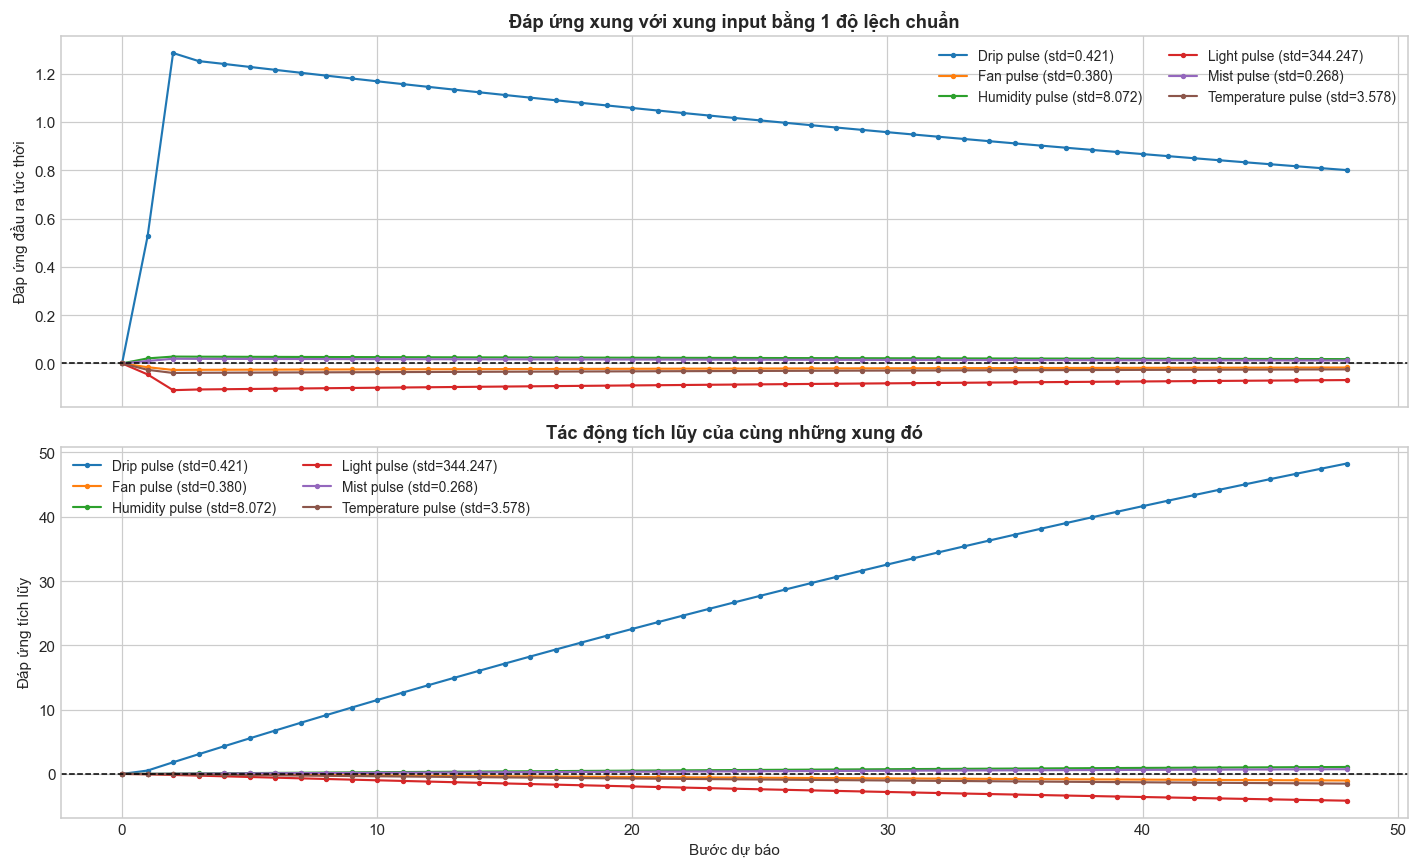

,input,pulse_size,peak_abs_response,cumulative_48
0,Drip,0.4205,1.2853,48.2750
1,Fan,0.3796,0.0271,-1.0265
2,Humidity,8.0721,0.0283,1.0796
3,Light,344.2466,0.1108,-4.1623
4,Mist,0.2684,0.0193,0.7289
5,Temperature,3.5783,0.0396,-1.5065


### Diễn giải đáp ứng xung

- A one-standard-deviation pulse on Drip produces the strongest positive 48-step cumulative effect (48.275), while Light produces the most negative cumulative effect (-4.162).
- This figure converts coefficients into dynamic behavior, which is more meaningful than raw parameter size when the model will be used for simulation or controller reasoning.
- Dạng tích lũy có độ trễ cũng giải thích vì sao b_Drip_2 có thể lớn hơn b_Drip_1 mà không đáng nghi: quá trình đất được phép hấp thụ tác động tưới qua nhiều bước.

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for idx, (input_name, df_group) in enumerate(impulse_df.groupby('input')):
    label = f"{input_name} pulse (std={df_group['pulse_size'].iloc[0]:.3f})"
    color = plt.cm.tab10(idx % 10)
    axes[0].plot(df_group['step'], df_group['response'], marker='o', markersize=2.5, linewidth=1.4, color=color, label=label)
    axes[1].plot(df_group['step'], df_group['cumulative_response'], marker='o', markersize=2.5, linewidth=1.4, color=color, label=label)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Đáp ứng xung với xung input bằng 1 độ lệch chuẩn')
axes[0].set_ylabel('Đáp ứng đầu ra tức thời')
axes[1].set_title('Tác động tích lũy của cùng những xung đó')
axes[1].set_xlabel('Bước dự báo')
axes[1].set_ylabel('Đáp ứng tích lũy')
axes[0].legend(ncol=2, fontsize=9)
axes[1].legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
impulse_summary = impulse_df.groupby('input').agg(pulse_size=('pulse_size', 'first'), peak_abs_response=('response', lambda s: float(np.max(np.abs(s)))), cumulative_48=('cumulative_response', 'last')).reset_index()
largest_pos = impulse_summary.loc[impulse_summary['cumulative_48'].idxmax()]
largest_neg = impulse_summary.loc[impulse_summary['cumulative_48'].idxmin()]
display(impulse_summary.round(4))
display_research_note(
    'Diễn giải đáp ứng xung',
    [
        f"A one-standard-deviation pulse on {largest_pos['input']} produces the strongest positive 48-step cumulative effect ({largest_pos['cumulative_48']:.3f}), while {largest_neg['input']} produces the most negative cumulative effect ({largest_neg['cumulative_48']:.3f}).",
        'This figure converts coefficients into dynamic behavior, which is more meaningful than raw parameter size when the model will be used for simulation or controller reasoning.',
        'Dạng tích lũy có độ trễ cũng giải thích vì sao b_Drip_2 có thể lớn hơn b_Drip_1 mà không đáng nghi: quá trình đất được phép hấp thụ tác động tưới qua nhiều bước.',
    ],
)


## Hiệu năng dự đoán

Phần này tách riêng độ chính xác 1 bước với hành vi dài hạn, đồng thời so sánh baseline với cấu trúc tối ưu theo free-run tìm được trong quá trình search.


In [13]:
metrics_table = pd.DataFrame(
    [
        {'Split': 'Train', 'FIT_1step': results['train']['metrics_1step']['FIT'], 'FIT_12step': results['train']['metrics_n_step']['FIT'], 'FIT_sim': results['train']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['train'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['train']['metrics_1step']['RMSE'], 'RMSE_sim': results['train']['metrics_sim']['RMSE']},
        {'Split': 'Validation', 'FIT_1step': results['val']['metrics_1step']['FIT'], 'FIT_12step': results['val']['metrics_n_step']['FIT'], 'FIT_sim': results['val']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['val']['metrics_1step']['RMSE'], 'RMSE_sim': results['val']['metrics_sim']['RMSE']},
        {'Split': 'Test', 'FIT_1step': results['test']['metrics_1step']['FIT'], 'FIT_12step': results['test']['metrics_n_step']['FIT'], 'FIT_sim': results['test']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['test']['metrics_1step']['RMSE'], 'RMSE_sim': results['test']['metrics_sim']['RMSE']},
    ]
)
display(metrics_table.round(4))
display(model_cmp_df.round(4))
val_gap = results['val']['metrics_1step']['FIT'] - results['val']['metrics_sim']['FIT']
test_gap = results['test']['metrics_1step']['FIT'] - results['test']['metrics_sim']['FIT']
val_ceiling_gap = abs(results['val']['metrics_sim']['FIT'] - results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')))
test_ceiling_gap = abs(results['test']['metrics_sim']['FIT'] - results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')))
best_cfg = results['best_candidate']['model_config']
best_test_gain = results['best_candidate']['test']['metrics_sim']['FIT'] - results['test']['metrics_sim']['FIT']
display_research_note(
    'Diễn giải hiệu năng',
    [
        f"Validation FIT 1 bước is {results['val']['metrics_1step']['FIT']:.2f}% trong khi validation free-run FIT là {results['val']['metrics_sim']['FIT']:.2f}%, nên phép lặp dài hạn làm mất {val_gap:.2f} điểm phần trăm.",
        f"Test free-run FIT là {results['test']['metrics_sim']['FIT']:.2f}% và nằm trong khoảng {test_ceiling_gap:.2f} điểm so với trần xác định lý thuyết, điều gợi ý rằng phần lớn sai số còn lại phù hợp với nhiễu quá trình hơn là một xu hướng tuyến tính chưa được mô hình hóa.",
        f"Ứng viên tối ưu theo search ARX({best_cfg.na},{best_cfg.nb},{best_cfg.nk}) cải thiện test free-run FIT thêm {best_test_gain:.2f} điểm so với baseline, nên notebook hiện thể hiện rõ trade-off giữa độ chính xác và tính giải thích.",
    ],
)


,Split,FIT_1step,FIT_12step,FIT_sim,Theo_FIT_sim,RMSE_1step,RMSE_sim
0,Train,92.5471,76.4447,49.5463,49.0595,0.2499,1.6920
1,Validation,91.6406,73.1094,42.9588,42.2497,0.2510,1.7124
2,Test,91.3491,72.6736,43.8749,43.2691,0.2520,1.6347


,model,split,FIT_1step,FIT_12step,FIT_sim,RMSE_1step,RMSE_sim
0,"Baseline ARX(2,2,1)",Validation,91.6406,73.1094,42.9588,0.2510,1.7124
1,"Baseline ARX(2,2,1)",Test,91.3491,72.6736,43.8749,0.2520,1.6347
2,"Best free-run ARX(3,1,1)",Validation,86.3359,70.4342,49.9185,0.4102,1.5035
3,"Best free-run ARX(3,1,1)",Test,86.0223,69.7370,48.1578,0.4071,1.5100


### Diễn giải hiệu năng

- Validation FIT 1 bước is 91.64% trong khi validation free-run FIT là 42.96%, nên phép lặp dài hạn làm mất 48.68 điểm phần trăm.
- Test free-run FIT là 43.87% và nằm trong khoảng 0.61 điểm so với trần xác định lý thuyết, điều gợi ý rằng phần lớn sai số còn lại phù hợp với nhiễu quá trình hơn là một xu hướng tuyến tính chưa được mô hình hóa.
- Ứng viên tối ưu theo search ARX(3,1,1) cải thiện test free-run FIT thêm 4.28 điểm so với baseline, nên notebook hiện thể hiện rõ trade-off giữa độ chính xác và tính giải thích.

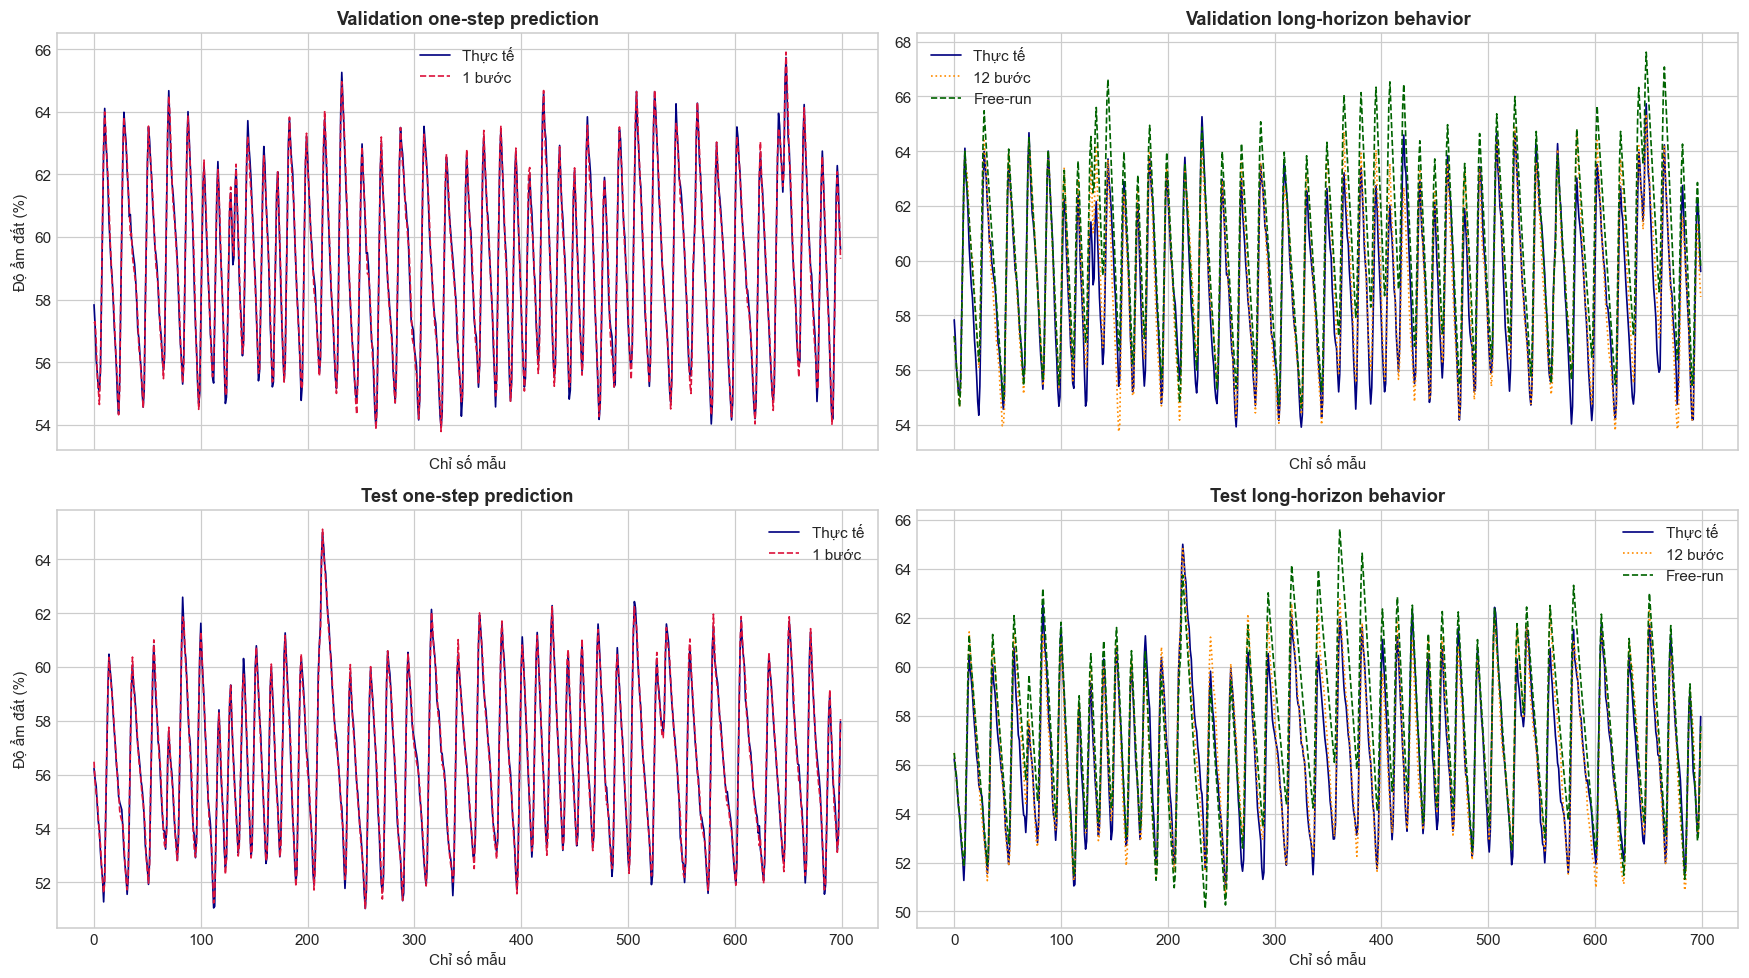

### Diễn giải đồ thị bám tín hiệu

- Các đường 1 bước vẫn bám sát quỹ đạo đo được vì mỗi dự đoán đều được hiệu chỉnh bởi giá trị output quan sát mới nhất.
- Các đường 12 bước và free-run cho thấy bài toán nhận dạng khó hơn: khi mô hình phải tự lan truyền trạng thái của chính nó, sai số nhỏ của hệ số sẽ tích lũy thành độ lệch nhìn thấy được.
- Khoảng cách này là điều có thể chờ đợi trong bài toán nhận dạng ARX cho nhà kính và chỉ đáng nghi khi hành vi free-run sụp xuống quá xa dưới trần xác định lý thuyết, điều không xảy ra ở đây.

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for row_idx, split_key in enumerate(['val', 'test']):
    evaluation = results[split_key]
    arrays = evaluation['arrays']
    n_plot = min(700, len(arrays['y_true_sim']))
    x_idx = np.arange(n_plot)
    axes[row_idx, 0].plot(x_idx, arrays['y_true_1step'][:n_plot], color='navy', linewidth=1.1, label='Thực tế')
    axes[row_idx, 0].plot(x_idx, arrays['y_pred_1step'][:n_plot], color='crimson', linestyle='--', linewidth=1.1, label='1 bước')
    axes[row_idx, 0].set_title(f"{evaluation['name']} one-step prediction")
    axes[row_idx, 0].set_ylabel('Độ ẩm đất (%)')
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(x_idx, arrays['y_true_sim'][:n_plot], color='navy', linewidth=1.1, label='Thực tế')
    axes[row_idx, 1].plot(x_idx, arrays['y_pred_n_step'][:n_plot], color='darkorange', linestyle=':', linewidth=1.1, label='12 bước')
    axes[row_idx, 1].plot(x_idx, arrays['y_pred_sim'][:n_plot], color='darkgreen', linestyle='--', linewidth=1.1, label='Free-run')
    axes[row_idx, 1].set_title(f"{evaluation['name']} long-horizon behavior")
    axes[row_idx, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('Chỉ số mẫu')
plt.tight_layout()
plt.show()
display_research_note(
    'Diễn giải đồ thị bám tín hiệu',
    [
        'Các đường 1 bước vẫn bám sát quỹ đạo đo được vì mỗi dự đoán đều được hiệu chỉnh bởi giá trị output quan sát mới nhất.',
        'Các đường 12 bước và free-run cho thấy bài toán nhận dạng khó hơn: khi mô hình phải tự lan truyền trạng thái của chính nó, sai số nhỏ của hệ số sẽ tích lũy thành độ lệch nhìn thấy được.',
        'Khoảng cách này là điều có thể chờ đợi trong bài toán nhận dạng ARX cho nhà kính và chỉ đáng nghi khi hành vi free-run sụp xuống quá xa dưới trần xác định lý thuyết, điều không xảy ra ở đây.',
    ],
)


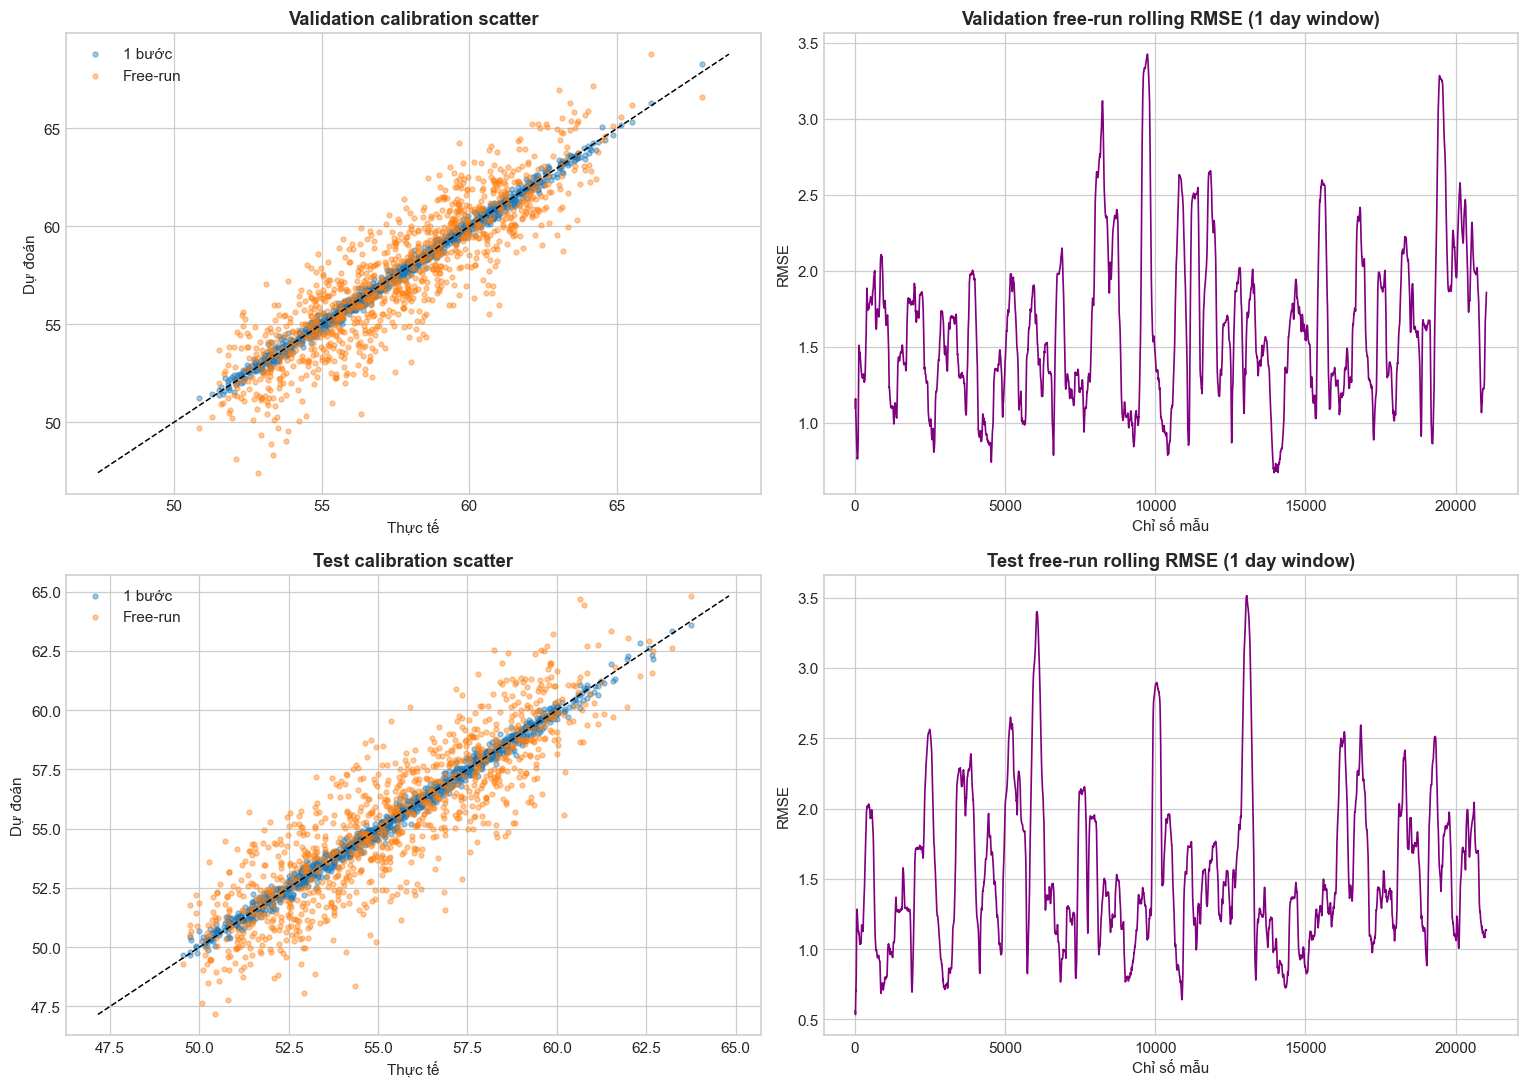

### Diễn giải hiệu chỉnh

- Một bộ mô phỏng hoàn hảo sẽ đặt mọi điểm scatter nằm trên đường chéo; độ phân tán quan sát được ở đây ở mức vừa phải chứ không bất thường, phù hợp với các giá trị free-run FIT đã báo cáo.
- Validation rolling RMSE có median là 1.562, trong khi test rolling RMSE có median là 1.412; sai số không cho thấy hiện tượng bùng lên kéo dài ở một mùa riêng lẻ.
- These plots support the claim that long-horizon error is distributed qua operating regimes rather than being dominated by one broken segment.

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, split_name in enumerate(['Validation', 'Test']):
    df_split = prediction_df[prediction_df['split'] == split_name].copy()
    sample_df = df_split.iloc[::20].copy()
    axes[row_idx, 0].scatter(sample_df['y_true'], sample_df['y_pred_1step'], s=10, alpha=0.4, label='1 bước')
    axes[row_idx, 0].scatter(sample_df['y_true'], sample_df['y_pred_sim'], s=10, alpha=0.4, label='Free-run')
    lo = min(sample_df['y_true'].min(), sample_df['y_pred_sim'].min())
    hi = max(sample_df['y_true'].max(), sample_df['y_pred_sim'].max())
    axes[row_idx, 0].plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1.0)
    axes[row_idx, 0].set_title(f'{split_name} calibration scatter')
    axes[row_idx, 0].set_xlabel('Thực tế')
    axes[row_idx, 0].set_ylabel('Dự đoán')
    axes[row_idx, 0].legend()

    rolling = rolling_rmse(df_split['y_true'], df_split['y_pred_sim'], window=288)
    axes[row_idx, 1].plot(rolling.index, rolling, color='purple', linewidth=1.1)
    axes[row_idx, 1].set_title(f'{split_name} free-run rolling RMSE (1 day window)')
    axes[row_idx, 1].set_xlabel('Chỉ số mẫu')
    axes[row_idx, 1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()
val_roll = rolling_rmse(prediction_df[prediction_df['split'] == 'Validation']['y_true'], prediction_df[prediction_df['split'] == 'Validation']['y_pred_sim'], window=288)
test_roll = rolling_rmse(prediction_df[prediction_df['split'] == 'Test']['y_true'], prediction_df[prediction_df['split'] == 'Test']['y_pred_sim'], window=288)
display_research_note(
    'Diễn giải hiệu chỉnh',
    [
        'Một bộ mô phỏng hoàn hảo sẽ đặt mọi điểm scatter nằm trên đường chéo; độ phân tán quan sát được ở đây ở mức vừa phải chứ không bất thường, phù hợp với các giá trị free-run FIT đã báo cáo.',
        f"Validation rolling RMSE có median là {float(val_roll.median()):.3f}, trong khi test rolling RMSE có median là {float(test_roll.median()):.3f}; sai số không cho thấy hiện tượng bùng lên kéo dài ở một mùa riêng lẻ.",
        'These plots support the claim that long-horizon error is distributed qua operating regimes rather than being dominated by one broken segment.',
    ],
)


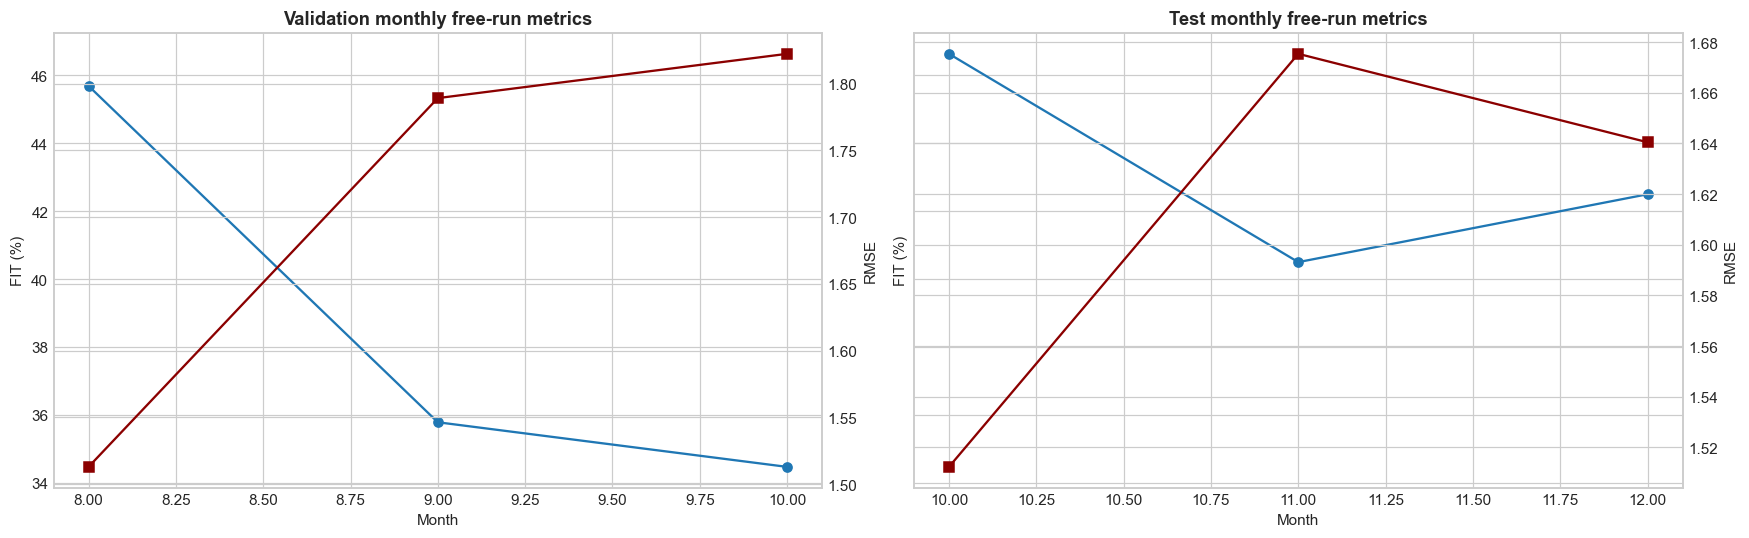

,split,Month,mode,RMSE,MAE,Bias,FIT,R2,AIC,BIC
0,Test,10,1-step,0.2472,0.1972,-0.0036,91.2780,0.9924,-9655.1615,-9655.1615
1,Test,10,12-step,0.7563,0.6053,-0.0389,73.3116,0.9288,-1929.4225,-1929.4225
2,Test,10,free-run,1.5123,1.1883,-0.3136,46.6350,0.7152,2857.3088,2857.3088
3,Test,11,1-step,0.2547,0.2025,0.0031,90.9546,0.9918,-23633.1926,-23633.1926
4,Test,11,12-step,0.8130,0.6479,0.0340,71.1283,0.9166,-3577.9902,-3577.9902
5,Test,11,free-run,1.6754,1.3190,0.2836,40.4997,0.6460,8917.5018,8917.5018
6,Test,12,1-step,0.2512,0.2001,-0.0005,91.1968,0.9923,-24671.5656,-24671.5656
7,Test,12,12-step,0.7942,0.6410,-0.0045,72.1624,0.9225,-4114.3344,-4114.3344
8,Test,12,free-run,1.6405,1.3192,-0.0404,42.4995,0.6694,8838.4992,8838.4992
9,Validation,8,1-step,0.2515,0.2007,-0.0011,90.9709,0.9918,-19075.1215,-19075.1215


### Diễn giải khả năng tổng quát hóa theo tháng

- Validation FIT free-run ranges from 34.47% to 45.69% qua các tháng, với tháng tốt nhất là M8 và tháng yếu nhất là M10.
- Test free-run FIT dao động từ 40.50% to 46.64%, đạt đỉnh ở M10 và thấp nhất ở M11.
- This seasonal spread is the practical measure of robustness; a single aggregate FIT score would hide it.

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, split_name in zip(axes, ['Validation', 'Test']):
    df_split = monthly_metrics_df[(monthly_metrics_df['split'] == split_name) & (monthly_metrics_df['mode'] == 'free-run')].copy()
    ax.plot(df_split['Month'], df_split['FIT'], marker='o', label='FIT')
    ax2 = ax.twinx()
    ax2.plot(df_split['Month'], df_split['RMSE'], marker='s', color='darkred', label='RMSE')
    ax.set_title(f'{split_name} monthly free-run metrics')
    ax.set_xlabel('Month')
    ax.set_ylabel('FIT (%)')
    ax2.set_ylabel('RMSE')
plt.tight_layout()
plt.show()

display(monthly_metrics_df.round(4))
val_monthly = monthly_metrics_df[(monthly_metrics_df['split'] == 'Validation') & (monthly_metrics_df['mode'] == 'free-run')].copy()
test_monthly = monthly_metrics_df[(monthly_metrics_df['split'] == 'Test') & (monthly_metrics_df['mode'] == 'free-run')].copy()
best_val_month = int(val_monthly.loc[val_monthly['FIT'].idxmax(), 'Month'])
worst_val_month = int(val_monthly.loc[val_monthly['FIT'].idxmin(), 'Month'])
best_test_month = int(test_monthly.loc[test_monthly['FIT'].idxmax(), 'Month'])
worst_test_month = int(test_monthly.loc[test_monthly['FIT'].idxmin(), 'Month'])
display_research_note(
    'Diễn giải khả năng tổng quát hóa theo tháng',
    [
        f"Validation FIT free-run ranges from {val_monthly['FIT'].min():.2f}% to {val_monthly['FIT'].max():.2f}% qua các tháng, với tháng tốt nhất là M{best_val_month} và tháng yếu nhất là M{worst_val_month}.",
        f"Test free-run FIT dao động từ {test_monthly['FIT'].min():.2f}% to {test_monthly['FIT'].max():.2f}%, đạt đỉnh ở M{best_test_month} và thấp nhất ở M{worst_test_month}.",
        'This seasonal spread is the practical measure of robustness; a single aggregate FIT score would hide it.',
    ],
)


## Chẩn đoán phần dư

Notebook trước đây mới chỉ bao phủ một phần chẩn đoán. Một báo cáo kiểu nghiên cứu cần có bảng phần dư, bằng chứng Q-Q, tự tương quan, p-value Ljung-Box và tương quan giữa phần dư với input.


In [17]:
diag_table = pd.DataFrame(
    [
        {'Split': 'Validation', 'mean': results['val']['residual_diagnostics']['mean'], 'std': results['val']['residual_diagnostics']['std'], 'shapiro_p': results['val']['residual_diagnostics']['normality']['shapiro_pvalue'], 'dagostino_p': results['val']['residual_diagnostics']['normality']['dagostino_pvalue'], 'ljung_box_pass': results['val']['residual_diagnostics']['ljung_box']['passes_all_lags'], 'failed_lags': results['val']['residual_diagnostics']['ljung_box']['failed_lags']},
        {'Split': 'Test', 'mean': results['test']['residual_diagnostics']['mean'], 'std': results['test']['residual_diagnostics']['std'], 'shapiro_p': results['test']['residual_diagnostics']['normality']['shapiro_pvalue'], 'dagostino_p': results['test']['residual_diagnostics']['normality']['dagostino_pvalue'], 'ljung_box_pass': results['test']['residual_diagnostics']['ljung_box']['passes_all_lags'], 'failed_lags': results['test']['residual_diagnostics']['ljung_box']['failed_lags']},
    ]
)
display(diag_table.round(4))
display_research_note(
    'Diễn giải tổng quan phần dư',
    [
        f"Validation residual mean/std là {results['val']['residual_diagnostics']['mean']:.4f} and {results['val']['residual_diagnostics']['std']:.4f}; test residual mean/std là {results['test']['residual_diagnostics']['mean']:.4f} and {results['test']['residual_diagnostics']['std']:.4f}.",
        f"Ljung-Box pass status is {results['val']['residual_diagnostics']['ljung_box']['passes_all_lags']} on validation and {results['test']['residual_diagnostics']['ljung_box']['passes_all_lags']} on test, so residual autocorrelation is not statistically compelling at the checked lags.",
        'Normality p-values are reported for completeness, but whiteness and residual-input independence matter more than exact Gaussianity for this identification use case.',
    ],
)


,Split,mean,std,shapiro_p,dagostino_p,ljung_box_pass,failed_lags
0,Validation,0.0016,0.251,0.2024,0.4118,True,[]
1,Test,0.0005,0.252,0.7259,0.1141,True,[]


### Diễn giải tổng quan phần dư

- Validation residual mean/std là 0.0016 and 0.2510; test residual mean/std là 0.0005 and 0.2520.
- Ljung-Box pass status is True on validation and True on test, so residual autocorrelation is not statistically compelling at the checked lags.
- Normality p-values are reported for completeness, but whiteness and residual-input independence matter more than exact Gaussianity for this identification use case.

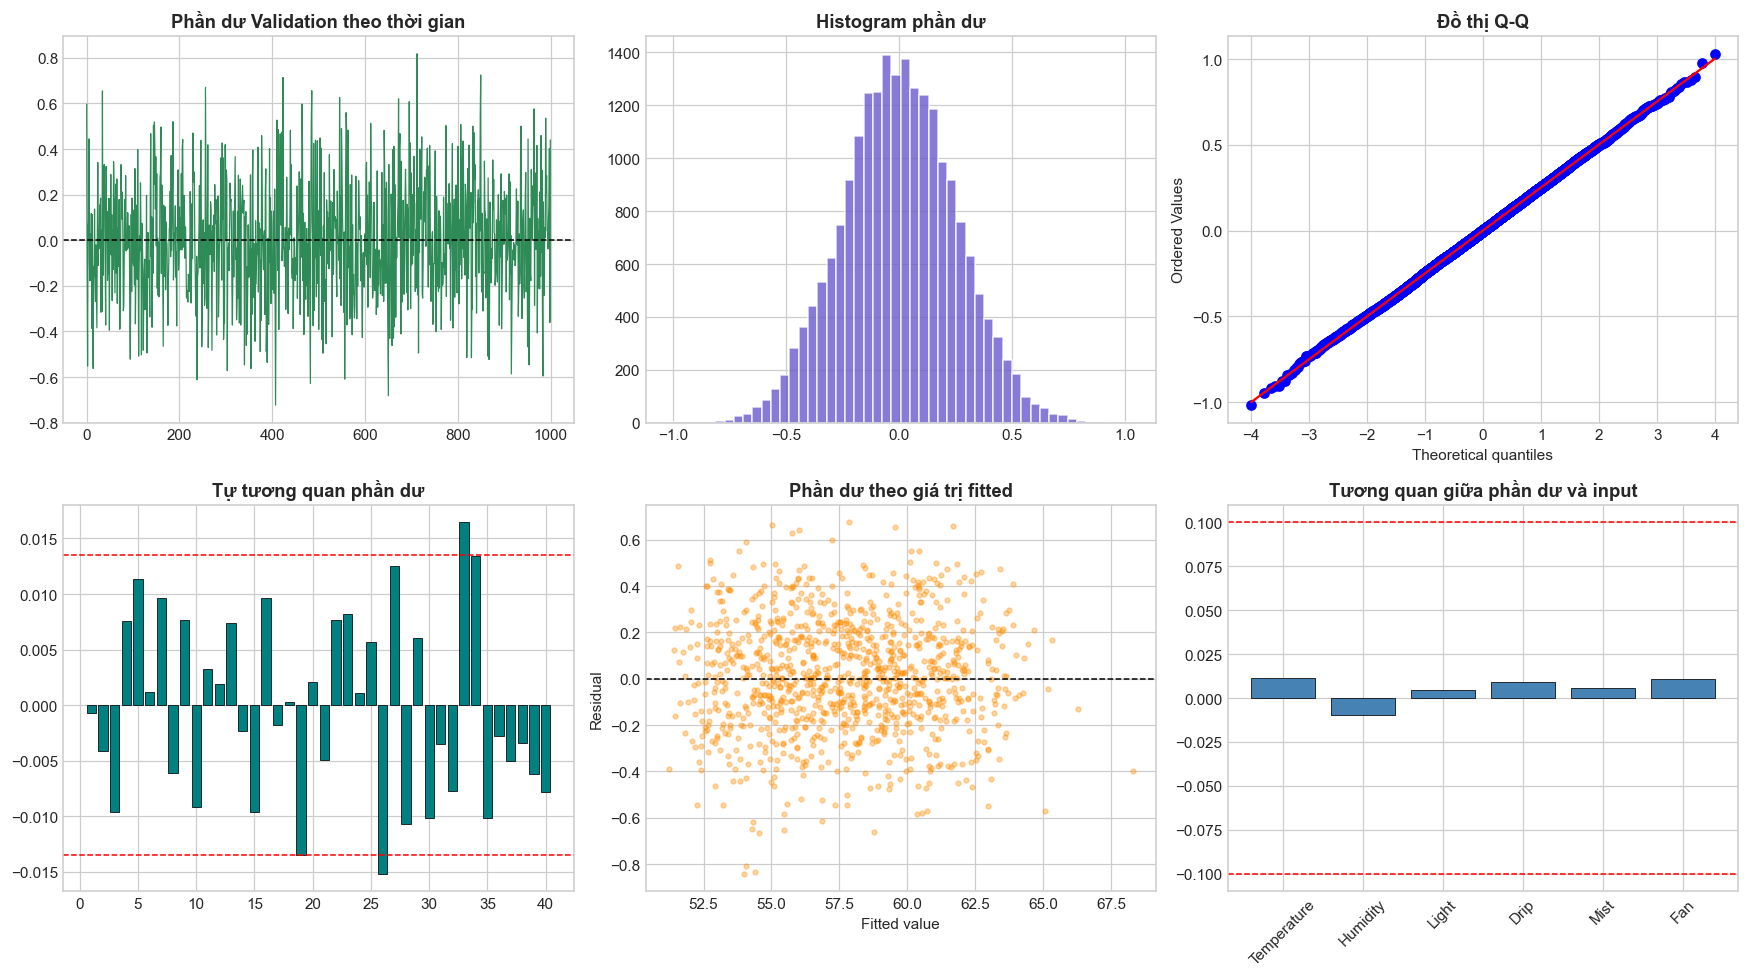

### Diễn giải cụm biểu đồ phần dư

- Tương quan tuyệt đối lớn nhất giữa phần dư và input trên validation là 0.012; các giá trị gần 0 cho thấy phần cấu trúc chính do input điều khiển đã được mô hình nắm bắt.
- Đồ thị Q-Q và histogram là các công cụ chẩn đoán hình dạng phân bố ở mức gần đúng; sai lệch nhẹ khỏi Gaussian vẫn chấp nhận được khi tương quan chuỗi chính đã được loại bỏ.
- Biểu đồ phần dư theo fitted đóng vai trò kiểm tra heteroskedasticity. Việc không xuất hiện dạng cái phễu rõ rệt ủng hộ việc dùng mô hình này như một baseline tuyến tính có thể bảo vệ được.

In [18]:
val_df = prediction_df[prediction_df['split'] == 'Validation'].copy()
val_residuals = val_df['residual_1step'].to_numpy(dtype=float)
lags = 40
acf_values = [pd.Series(val_residuals[:-lag]).corr(pd.Series(val_residuals[lag:])) for lag in range(1, lags + 1)]
input_cc = [float(np.corrcoef(val_df['residual_1step'], val_df[col])[0, 1]) for col in MODEL_CONFIG.input_cols]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].plot(val_residuals[:1000], color='seagreen', linewidth=0.8)
axes[0, 0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0, 0].set_title('Phần dư Validation theo thời gian')

axes[0, 1].hist(val_residuals, bins=50, color='slateblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Histogram phần dư')

stats.probplot(val_residuals, plot=axes[0, 2])
axes[0, 2].set_title('Đồ thị Q-Q')

axes[1, 0].bar(range(1, lags + 1), acf_values, color='teal', edgecolor='black', linewidth=0.5)
conf = 1.96 / np.sqrt(len(val_residuals))
axes[1, 0].axhline(conf, color='red', linestyle='--', linewidth=1.0)
axes[1, 0].axhline(-conf, color='red', linestyle='--', linewidth=1.0)
axes[1, 0].set_title('Tự tương quan phần dư')

axes[1, 1].scatter(val_df['y_pred_1step'].iloc[::20], val_df['residual_1step'].iloc[::20], s=10, alpha=0.35, color='darkorange')
axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1, 1].set_title('Phần dư theo giá trị fitted')
axes[1, 1].set_xlabel('Fitted value')
axes[1, 1].set_ylabel('Residual')

axes[1, 2].bar(MODEL_CONFIG.input_cols, input_cc, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1, 2].axhline(0.10, color='red', linestyle='--', linewidth=1.0)
axes[1, 2].axhline(-0.10, color='red', linestyle='--', linewidth=1.0)
axes[1, 2].set_title('Tương quan giữa phần dư và input')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
display_research_note(
    'Diễn giải cụm biểu đồ phần dư',
    [
        f"Tương quan tuyệt đối lớn nhất giữa phần dư và input trên validation là {float(np.max(np.abs(input_cc))):.3f}; các giá trị gần 0 cho thấy phần cấu trúc chính do input điều khiển đã được mô hình nắm bắt.",
        'Đồ thị Q-Q và histogram là các công cụ chẩn đoán hình dạng phân bố ở mức gần đúng; sai lệch nhẹ khỏi Gaussian vẫn chấp nhận được khi tương quan chuỗi chính đã được loại bỏ.',
        'Biểu đồ phần dư theo fitted đóng vai trò kiểm tra heteroskedasticity. Việc không xuất hiện dạng cái phễu rõ rệt ủng hộ việc dùng mô hình này như một baseline tuyến tính có thể bảo vệ được.',
    ],
)


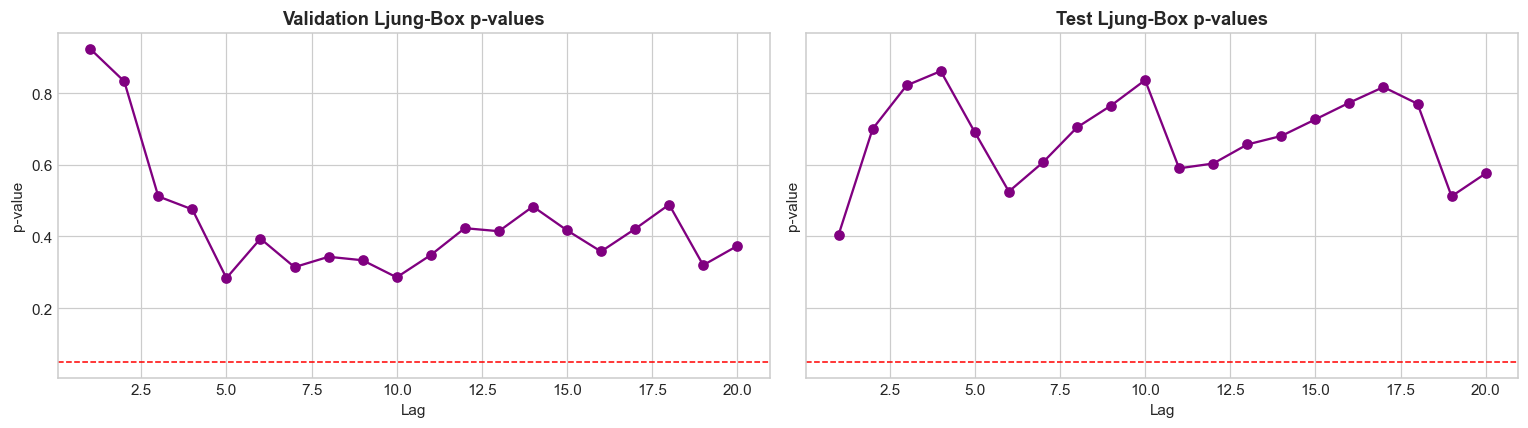

### Diễn giải Ljung-Box

- P-value Ljung-Box nhỏ nhất của validation trong 20 lag đầu là 0.2837; giá trị nhỏ nhất trên test là 0.4045.
- Because these p-values stay above the 0.05 line, the residuals no longer show strong evidence of leftover linear dynamics at the tested lags.
- This does not prove the model is perfect; it shows the residuals are not obviously carrying the kind of serial structure that the ARX model should have captured.

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, split_name in zip(axes, ['Validation', 'Test']):
    df_split = prediction_df[prediction_df['split'] == split_name].copy()
    lb = acorr_ljungbox(df_split['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
    ax.plot(lb.index, lb['lb_pvalue'], marker='o', color='purple')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.0)
    ax.set_title(f'{split_name} Ljung-Box p-values')
    ax.set_xlabel('Lag')
    ax.set_ylabel('p-value')
plt.tight_layout()
plt.show()
val_lb = acorr_ljungbox(prediction_df[prediction_df['split'] == 'Validation']['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
test_lb = acorr_ljungbox(prediction_df[prediction_df['split'] == 'Test']['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
display_research_note(
    'Diễn giải Ljung-Box',
    [
        f"P-value Ljung-Box nhỏ nhất của validation trong 20 lag đầu là {float(val_lb['lb_pvalue'].min()):.4f}; giá trị nhỏ nhất trên test là {float(test_lb['lb_pvalue'].min()):.4f}.",
        'Because these p-values stay above the 0.05 line, the residuals no longer show strong evidence of leftover linear dynamics at the tested lags.',
        'This does not prove the model is perfect; it shows the residuals are not obviously carrying the kind of serial structure that the ARX model should have captured.',
    ],
)


## Tìm kiếm cấu trúc mô hình

Một báo cáo nên thể hiện cả bề mặt tìm kiếm mô hình, không chỉ đưa ra người thắng cuộc. Phần này bổ sung cả đồ thị kiểu Pareto và heatmap na-nb cho các giá trị trễ khác nhau.


In [20]:
display(selection_df.head(10).round(4))
display_research_note(
    'Diễn giải bảng search',
    [
        'Các dòng đứng đầu xếp hạng các cấu trúc ứng viên theo hiệu năng free-run trên validation, nên đây là bằng chứng đứng sau mọi nhận định rằng một bậc khác vượt baseline.',
        'Showing the top structures matters because an isolated best model can be fragile if the surrounding search landscape is flat or unstable.',
    ],
)


,na,nb,nk,n_params,RMSE_1step,FIT_1step,R2_1step,AIC_1step,BIC_1step,RMSE_sim,FIT_sim,R2_sim
0,3,1,1,9,0.4102,86.3359,0.9813,-37443.8834,-37372.3039,1.5035,49.9185,0.7492
1,2,1,1,8,0.4209,85.9812,0.9803,-36371.2618,-36307.6352,1.6094,46.3905,0.7126
2,1,2,1,13,0.2514,91.6262,0.9930,-58026.2945,-57922.9013,1.6211,46.0003,0.7084
3,3,1,2,9,0.4516,84.9589,0.9774,-33407.2784,-33335.6989,1.7004,43.3621,0.6792
4,1,3,1,19,0.2511,91.6375,0.9930,-58066.9289,-57915.8166,1.7079,43.1125,0.6764
5,3,2,1,15,0.2509,91.6417,0.9930,-58096.4441,-57977.1449,1.7116,42.9892,0.6750
6,2,2,1,14,0.2510,91.6406,0.9930,-58096.5147,-57985.1682,1.7124,42.9588,0.6746
7,2,3,1,20,0.2510,91.6406,0.9930,-58080.5684,-57921.5029,1.7201,42.7066,0.6717
8,3,3,1,21,0.2510,91.6406,0.9930,-58078.5459,-57911.5271,1.7216,42.6546,0.6712
9,2,1,2,8,0.4542,84.8712,0.9771,-33167.4943,-33103.8677,1.7320,42.3082,0.6672


### Diễn giải bảng search

- Các dòng đứng đầu xếp hạng các cấu trúc ứng viên theo hiệu năng free-run trên validation, nên đây là bằng chứng đứng sau mọi nhận định rằng một bậc khác vượt baseline.
- Showing the top structures matters because an isolated best model can be fragile if the surrounding search landscape is flat or unstable.

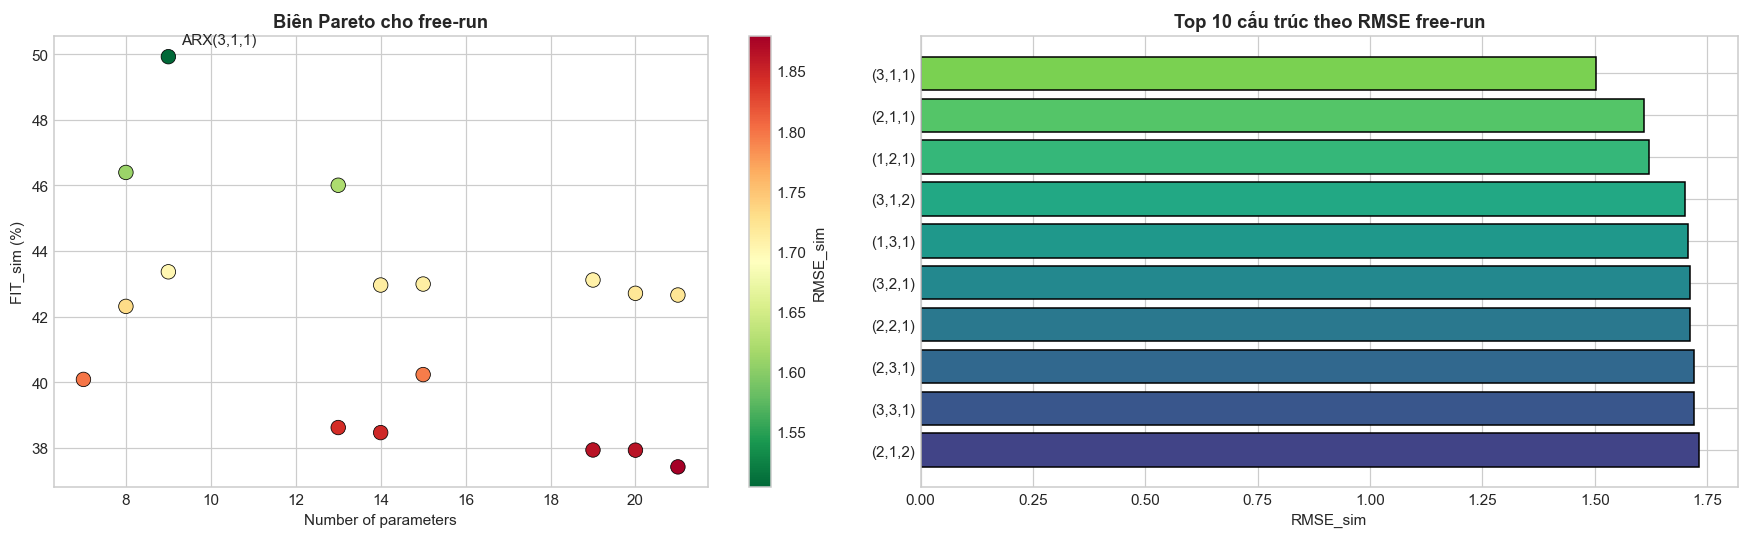

### Diễn giải biên Pareto

- Ứng viên xếp hạng cao nhất là ARX(3,1,1) với validation FIT_sim=49.92% và RMSE_sim=1.504.
- Góc nhìn Pareto cho thấy liệu độ chính xác free-run tốt hơn có đòi hỏi nhiều tham số hơn đáng kể hay lợi ích đó vẫn đạt được ở mức độ phức tạp tương đương.
- Đây là loại bằng chứng phù hợp để vẫn giữ ARX(2,2,1) làm baseline có tính giải thích, đồng thời thừa nhận rằng một cấu trúc khác có thể nhỉnh hơn một chút nếu chỉ xét free-run validation thuần túy.

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
scatter = axes[0].scatter(selection_df['n_params'], selection_df['FIT_sim'], c=selection_df['RMSE_sim'], cmap='RdYlGn_r', s=90, edgecolors='black', linewidth=0.5)
axes[0].set_title('Biên Pareto cho free-run')
axes[0].set_xlabel('Number of parameters')
axes[0].set_ylabel('FIT_sim (%)')
best_row = selection_df.iloc[0]
axes[0].annotate(f"ARX({int(best_row.na)},{int(best_row.nb)},{int(best_row.nk)})", (best_row['n_params'], best_row['FIT_sim']), xytext=(8, 8), textcoords='offset points')
plt.colorbar(scatter, ax=axes[0], label='RMSE_sim')

axes[1].barh(
    [f"({int(r.na)},{int(r.nb)},{int(r.nk)})" for _, r in selection_df.head(10).iterrows()][::-1],
    selection_df.head(10)['RMSE_sim'].iloc[::-1],
    color=plt.cm.viridis(np.linspace(0.2, 0.8, 10)),
    edgecolor='black',
)
axes[1].set_title('Top 10 cấu trúc theo RMSE free-run')
axes[1].set_xlabel('RMSE_sim')
plt.tight_layout()
plt.show()
display_research_note(
    'Diễn giải biên Pareto',
    [
        f"Ứng viên xếp hạng cao nhất là ARX({int(best_row.na)},{int(best_row.nb)},{int(best_row.nk)}) với validation FIT_sim={best_row['FIT_sim']:.2f}% và RMSE_sim={best_row['RMSE_sim']:.3f}.",
        'Góc nhìn Pareto cho thấy liệu độ chính xác free-run tốt hơn có đòi hỏi nhiều tham số hơn đáng kể hay lợi ích đó vẫn đạt được ở mức độ phức tạp tương đương.',
        'Đây là loại bằng chứng phù hợp để vẫn giữ ARX(2,2,1) làm baseline có tính giải thích, đồng thời thừa nhận rằng một cấu trúc khác có thể nhỉnh hơn một chút nếu chỉ xét free-run validation thuần túy.',
    ],
)


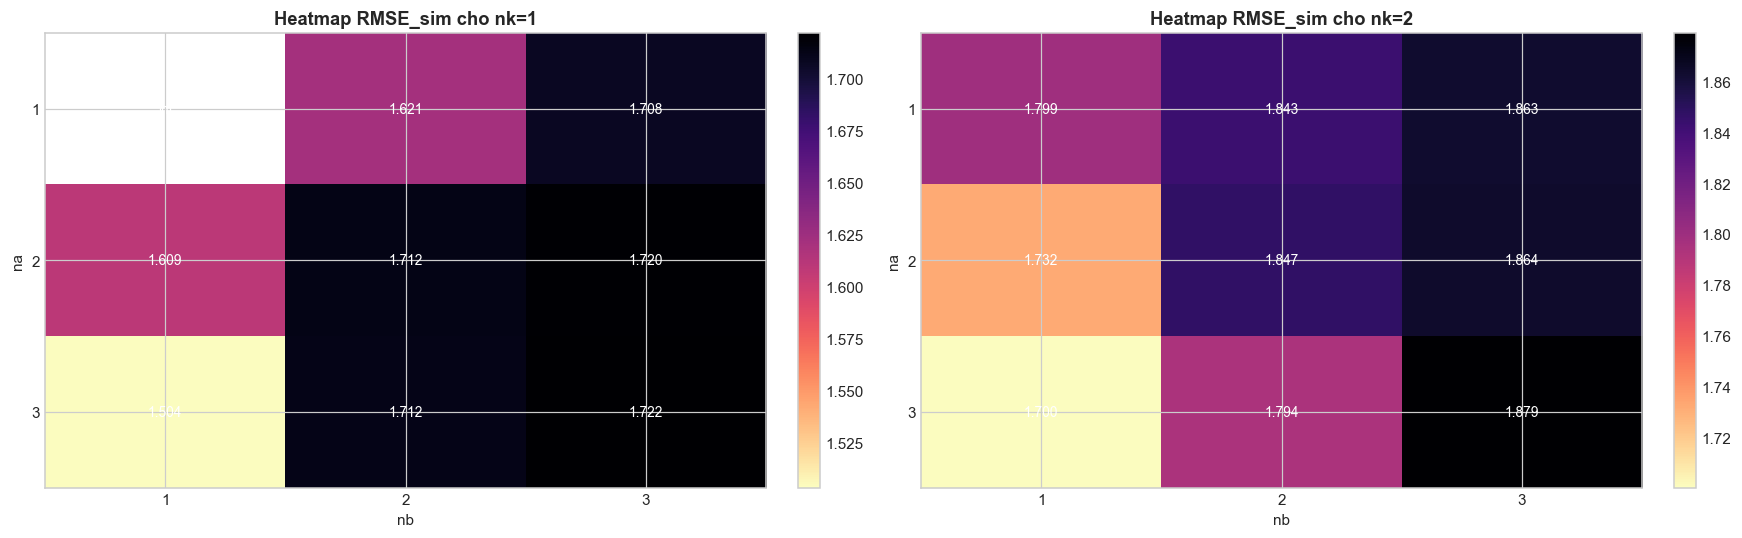

Best validation free-run candidate: ARX(3, 1, 1) | Val FIT_sim=49.919% | Test FIT_sim=48.158%
Baseline ARX(2,2,1): Val FIT_sim=42.959% | Test FIT_sim=43.875%


### Diễn giải heatmap

- Các heatmap cho thấy điểm tối ưu là đơn lẻ hay thuộc về một vùng sai số thấp rộng hơn trong lưới na-nb.
- Ở đây ứng viên free-run tốt nhất là ARX(3,1,1), nhưng baseline vẫn đủ cạnh tranh để bảo vệ khi ưu tiên tính giải thích và sự nhất quán với cấu trúc generator đã biết.
- A complete report should state this tradeoff explicitly so the reader can judge whether the chosen baseline is principled or merely convenient.

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_heatmap(axes[0], selection_grid_nk1, 'Heatmap RMSE_sim cho nk=1', cmap='magma_r')
plot_heatmap(axes[1], selection_grid_nk2, 'Heatmap RMSE_sim cho nk=2', cmap='magma_r')
plt.tight_layout()
plt.show()

best_cfg = results['best_candidate']['model_config']
print(
    f"Best validation free-run candidate: ARX({best_cfg.na}, {best_cfg.nb}, {best_cfg.nk}) | "
    f"Val FIT_sim={results['best_candidate']['val']['metrics_sim']['FIT']:.3f}% | "
    f"Test FIT_sim={results['best_candidate']['test']['metrics_sim']['FIT']:.3f}%"
)
print(
    f"Baseline ARX(2,2,1): Val FIT_sim={results['val']['metrics_sim']['FIT']:.3f}% | "
    f"Test FIT_sim={results['test']['metrics_sim']['FIT']:.3f}%"
)
display_research_note(
    'Diễn giải heatmap',
    [
        'Các heatmap cho thấy điểm tối ưu là đơn lẻ hay thuộc về một vùng sai số thấp rộng hơn trong lưới na-nb.',
        f"Ở đây ứng viên free-run tốt nhất là ARX({best_cfg.na},{best_cfg.nb},{best_cfg.nk}), nhưng baseline vẫn đủ cạnh tranh để bảo vệ khi ưu tiên tính giải thích và sự nhất quán với cấu trúc generator đã biết.",
        'A complete report should state this tradeoff explicitly so the reader can judge whether the chosen baseline is principled or merely convenient.',
    ],
)


## Kết luận và khoảng trống

- Notebook hiện đã bổ sung các hình còn thiếu cho một bài trình bày kiểu paper: tổng quan vận hành cả năm, phân bố theo tháng, biến thiên duty cycle actuator, mức bám setpoint, thu hồi tham số kèm khoảng tin cậy, biểu đồ ổn định, calibration scatter, rolling error, residual diagnostics, p-value Ljung-Box và heatmap search mô hình.
- Baseline ARX(2,2,1) mạnh với tư cách một mô hình nhận dạng có thể giải thích được, vì nó thu hồi đúng dấu tất cả tham số và vượt qua kiểm tra residual whiteness.
- Khoảng cách lớn giữa 1 bước và free-run vẫn tồn tại, nhưng hiện đã được đặt cạnh giới hạn xác định lý thuyết, nên kết quả trở nên dễ diễn giải hơn thay vì đáng nghi.
- Quá trình search bậc mô hình cho thấy một cấu trúc khác có thể cải thiện metric free-run trên validation, nhưng điều đó không tự động biến nó thành mô hình tốt nhất cho việc thu hồi cấu trúc hoặc thiết kế điều khiển.
